In [1]:
import torch
import torchvision

#https://github.com/JohannesTheo/multi_object_datasets_torch
# @misc{multiobjectdatasets19,
#   title={Multi-Object Datasets},
#   author={Kabra, Rishabh and Burgess, Chris and Matthey, Loic and
#           Kaufman, Raphael Lopez and Greff, Klaus and Reynolds, Malcolm and
#           Lerchner, Alexander},
#   howpublished={https://github.com/JohannesTheo/multi_object_datasets_torch},
#   year={2019}
# }
from multi_object_datasets_torch import MultiDSprites ,ClevrWithMasks,Tetrominoes


import model_solved as models
import tqdm
import argparse
import pickle
import matplotlib.pyplot as plt
import hungarian

In [2]:

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

parser = argparse.ArgumentParser()

model_dir='broadcastsup'
seed=0
batch_size=300
num_slots=7
num_iterations=3
hid_dim=64
learning_rate=10e-3
warmup_steps=2
decay_rate=0
num_workers=20
num_epochs=1000
decay_steps=num_epochs
reload=False

parser.add_argument('--model_dir', default=model_dir, type=str, help='where to save models' )
parser.add_argument('--seed', default=seed, type=int, help='random seed')
parser.add_argument('--batch_size', default=batch_size, type=int)
parser.add_argument('--num_slots', default=num_slots, type=int, help='# of slots')
parser.add_argument('--num_iterations', default=num_iterations, type=int, help='# iterations')
parser.add_argument('--hid_dim', default=hid_dim, type=int, help='hidden dimension size')
parser.add_argument('--learning_rate', default=learning_rate, type=float)
parser.add_argument('--warmup_steps', default=warmup_steps, type=int, help='# of warmup steps')
parser.add_argument('--decay_rate', default=decay_rate, type=float, help='decay rate')
parser.add_argument('--decay_steps', default=decay_steps, type=float, help='decay rate')
parser.add_argument('--num_workers', default=num_workers, type=int, help='# of workers for loading data')
parser.add_argument('--num_epochs', default=num_workers, type=int, help='# of epochs')

# opt = parser.parse_args()
# model_dir=opt.model_dir
# seed=opt.seed
# batch_size=opt.batch_size
# num_slots=opt.num_slots
# num_iterations=opt.num_iterations
# hid_dim=opt.hid_dim
# learning_rate=opt.learning_rate
# warmup_steps=opt.warmup_steps
# decay_rate=opt.decay_rate
# num_workers=opt.num_workers
# num_epochs=opt.num_epochs

_StoreAction(option_strings=['--num_epochs'], dest='num_epochs', nargs=None, const=None, default=20, type=<class 'int'>, choices=None, required=False, help='# of epochs', metavar=None)

In [3]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ConvertImageDtype(torch.float32),
])


In [4]:
train_set=Tetrominoes("data/Tetrominoes",download=True)
train_dataloader=torch.utils.data.DataLoader(train_set,batch_size=batch_size,shuffle=True,num_workers=num_workers)

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0

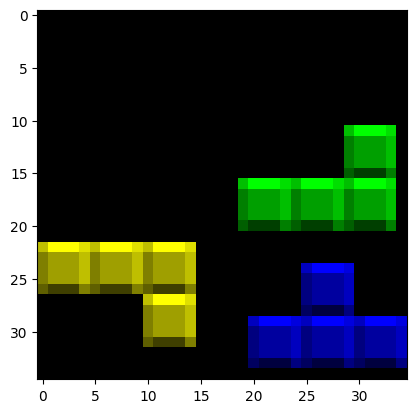

In [5]:
torch.manual_seed(seed)

visual=transform(train_set[0]['image'].unsqueeze(0)).to(device)
plt.imshow(visual.detach().to('cpu')[0,:,:,:].permute(1,2,0))
print(visual)

In [6]:
loss_evolution=[]
model=models.AutoEncoder(target_resolution=(35,35),slot_iterations=num_iterations,just_alpha=False,n_slots=num_slots).to(device)
if reload:
    model.load_state_dict(torch.load(model_dir+"/autosave.pt", weights_only=True), strict=False)
    with open(model_dir+"/stats.pkl",'rb') as r:
        loss_evolution=pickle.load(r)

In [7]:
def lr_sched(epoch):
    epoch+=1
    lr=learning_rate
    if epoch<warmup_steps:
        lr=lr/(epoch/warmup_steps)
    #lr*=decay_rate**(epoch/decay_steps)
    return lr

In [8]:
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
critres=torch.nn.MSELoss()
critmask=models.batch_matrix_hungarian_loss 
sched=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_sched)

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 8772.1689453125, epoch:0/1000


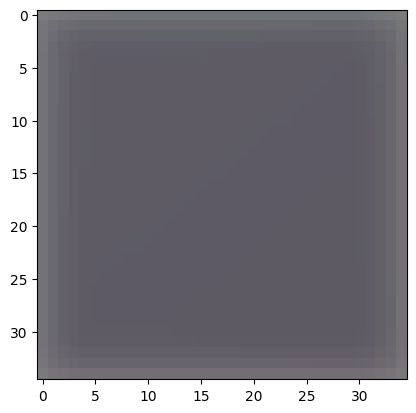

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7414.259765625, epoch:1/1000


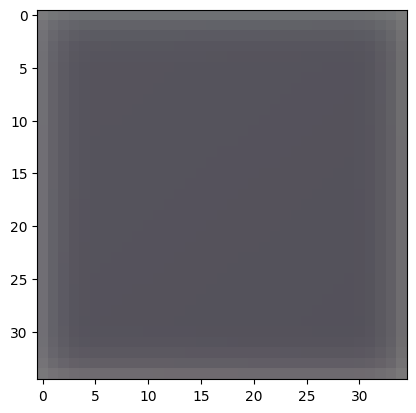

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7394.96337890625, epoch:2/1000


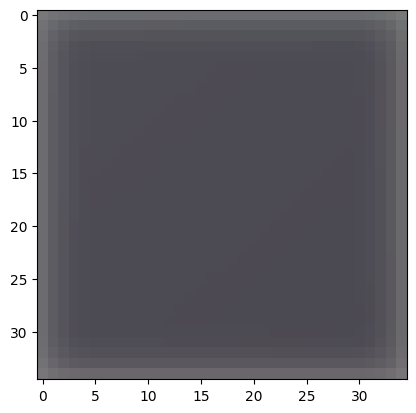

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7380.49560546875, epoch:3/1000


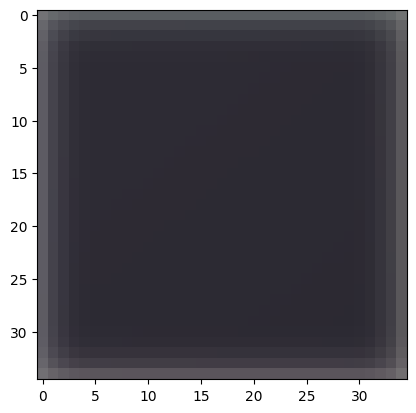

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7376.27294921875, epoch:4/1000


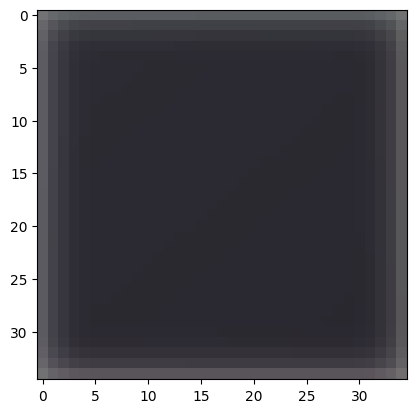

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7369.04443359375, epoch:5/1000


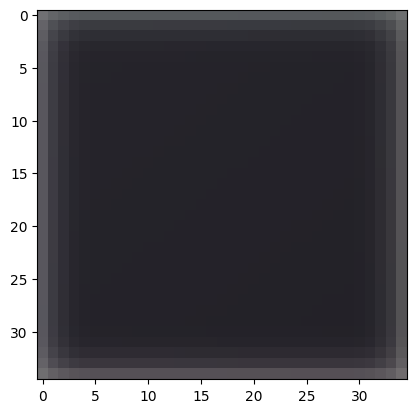

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7367.21484375, epoch:6/1000


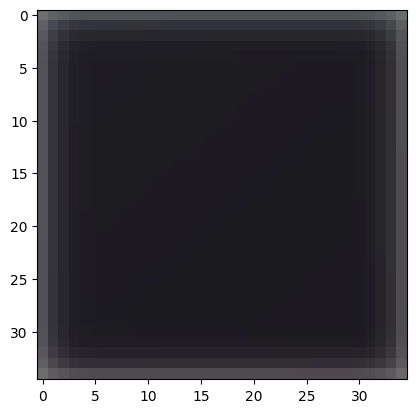

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7365.880859375, epoch:7/1000


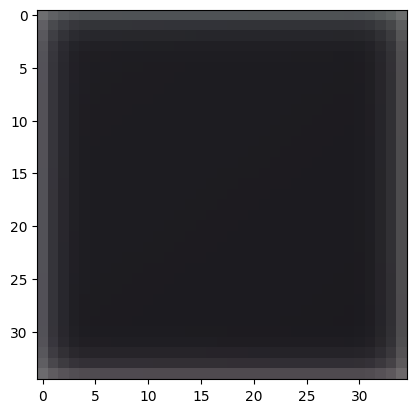

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7365.5380859375, epoch:8/1000


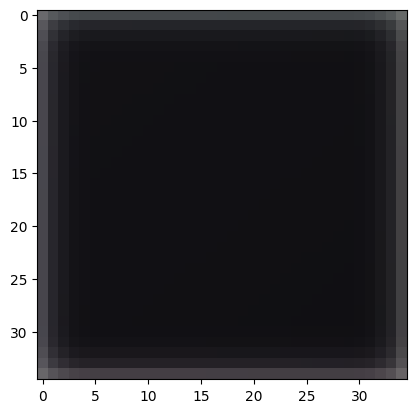

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7364.69384765625, epoch:9/1000


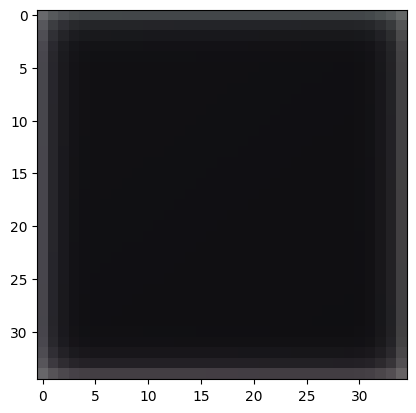

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]


loss: 7364.27587890625, epoch:10/1000


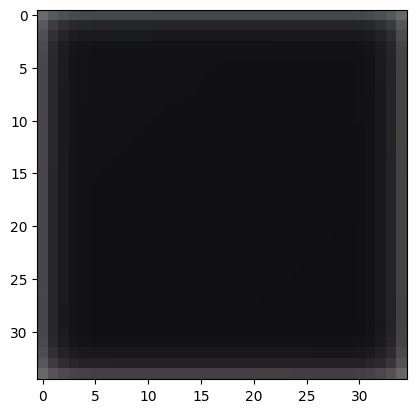

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7363.98583984375, epoch:11/1000


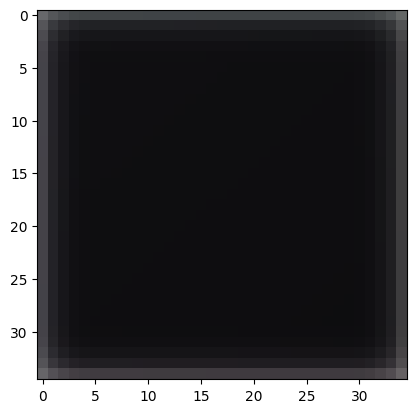

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7365.5947265625, epoch:12/1000


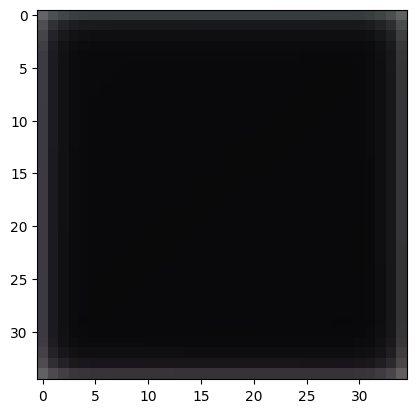

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7363.68896484375, epoch:13/1000


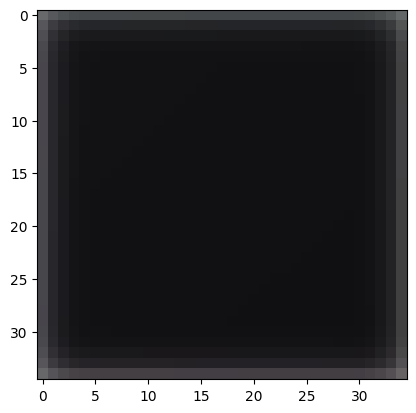

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7363.5439453125, epoch:14/1000


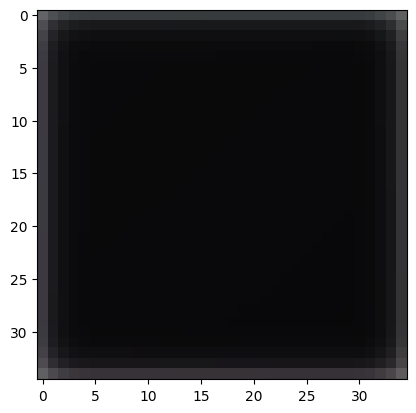

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7363.44384765625, epoch:15/1000


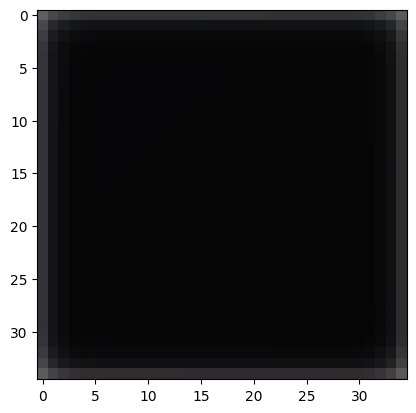

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7363.36767578125, epoch:16/1000


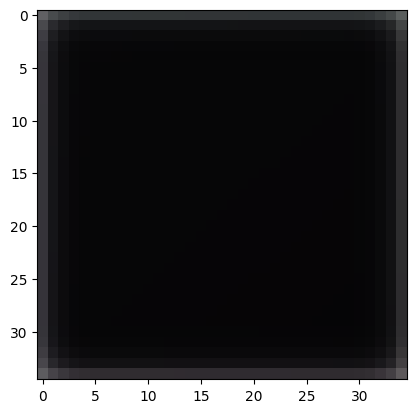

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7363.32666015625, epoch:17/1000


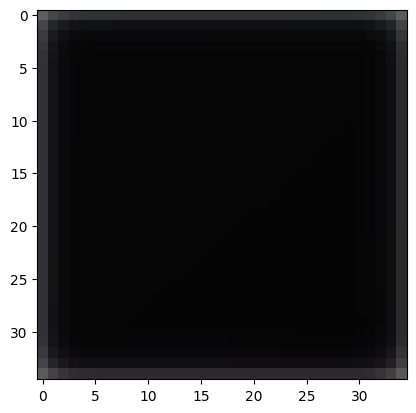

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7363.46240234375, epoch:18/1000


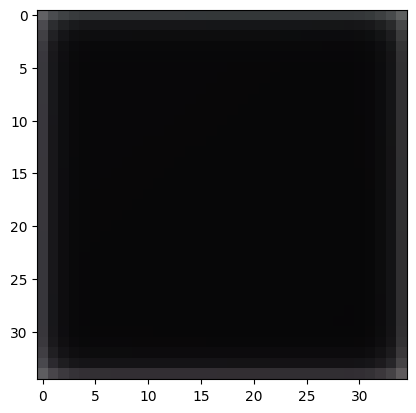

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7363.26806640625, epoch:19/1000


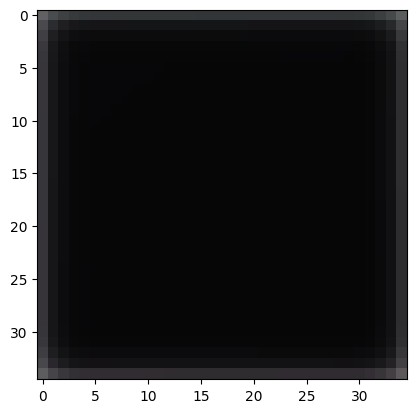

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]


loss: 7363.20361328125, epoch:20/1000


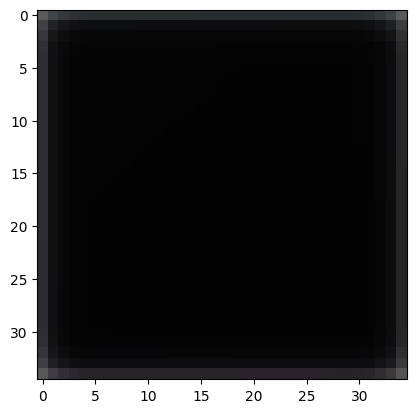

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7363.1728515625, epoch:21/1000


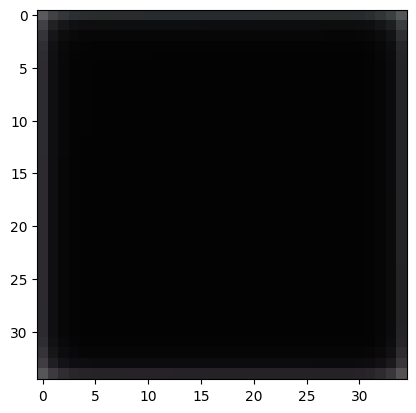

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7363.154296875, epoch:22/1000


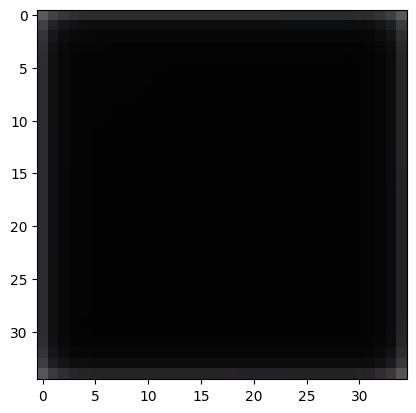

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7363.1357421875, epoch:23/1000


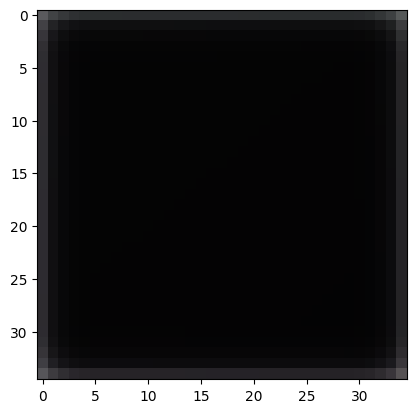

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7363.08251953125, epoch:24/1000


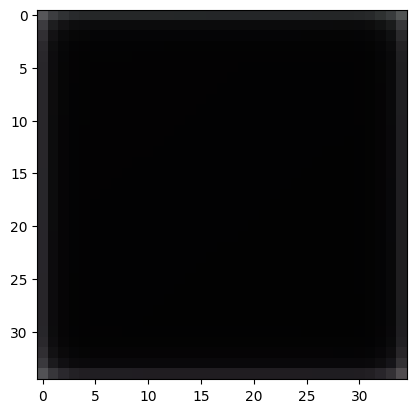

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7363.05126953125, epoch:25/1000


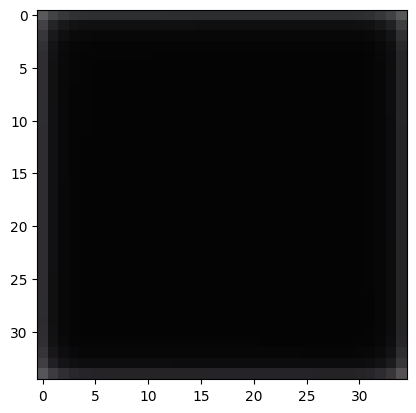

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7363.02978515625, epoch:26/1000


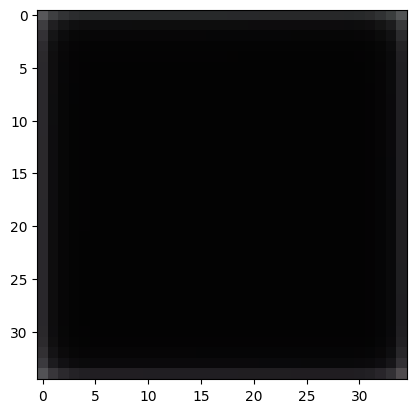

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7362.99365234375, epoch:27/1000


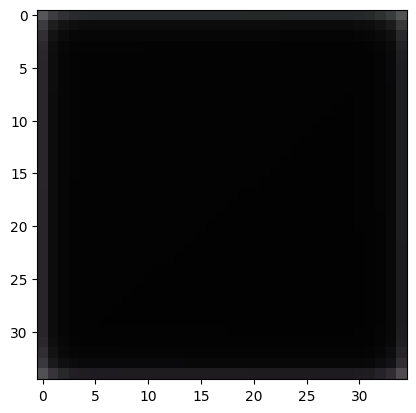

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7362.98095703125, epoch:28/1000


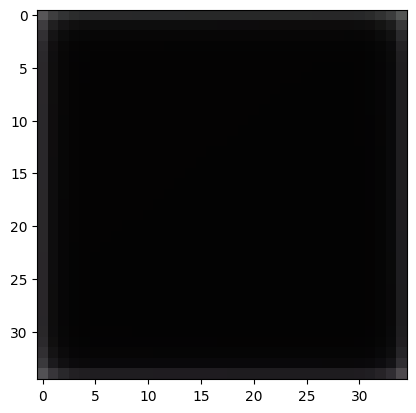

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7362.98193359375, epoch:29/1000


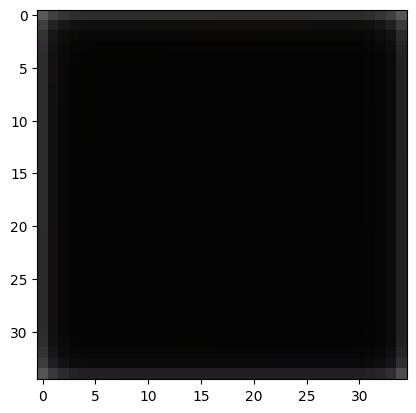

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7362.86767578125, epoch:30/1000


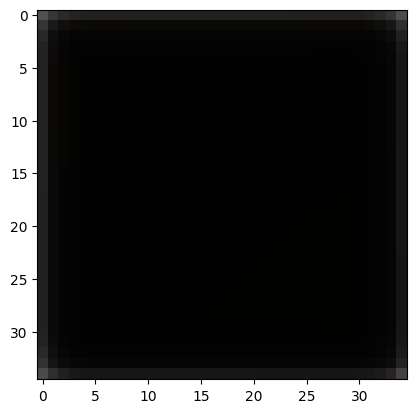

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7362.76513671875, epoch:31/1000


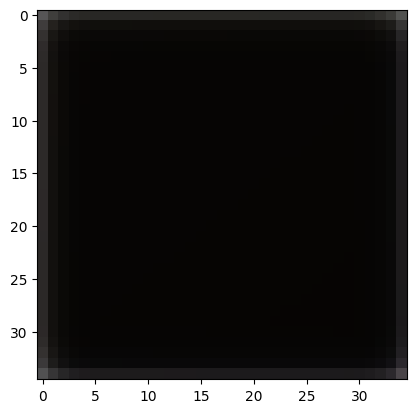

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7362.59033203125, epoch:32/1000


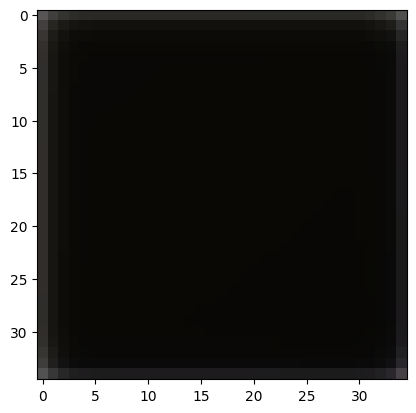

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7362.3447265625, epoch:33/1000


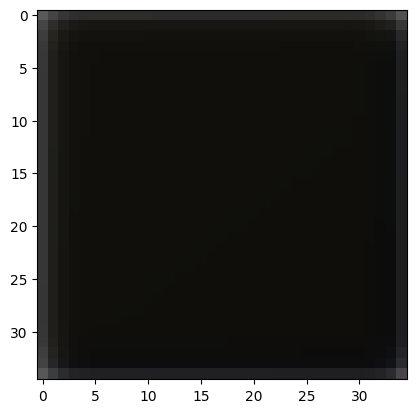

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7362.03515625, epoch:34/1000


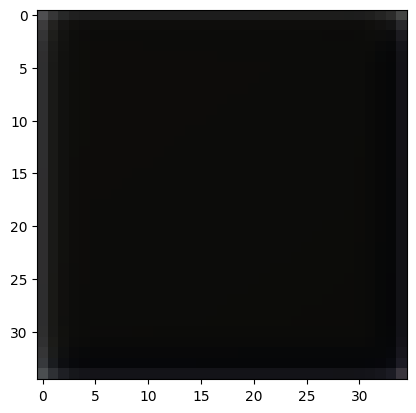

100%|██████████| 300/300 [01:09<00:00,  4.32it/s]


loss: 7361.86083984375, epoch:35/1000


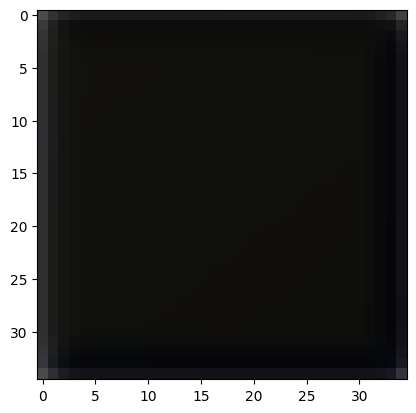

100%|██████████| 300/300 [01:09<00:00,  4.32it/s]


loss: 7361.556640625, epoch:36/1000


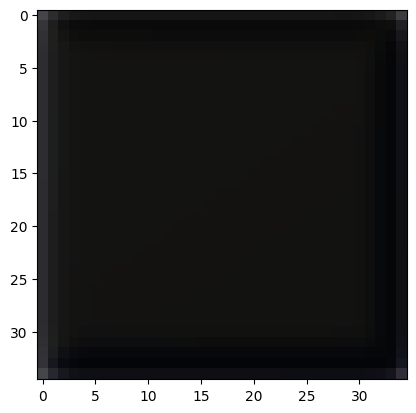

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]


loss: 7361.38330078125, epoch:37/1000


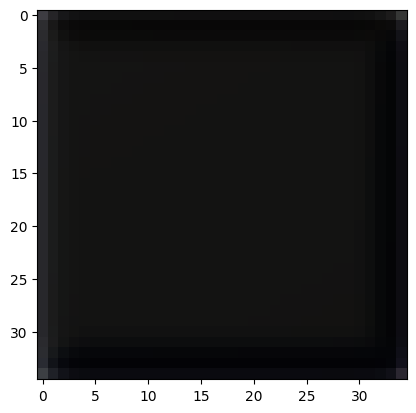

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]


loss: 7361.22314453125, epoch:38/1000


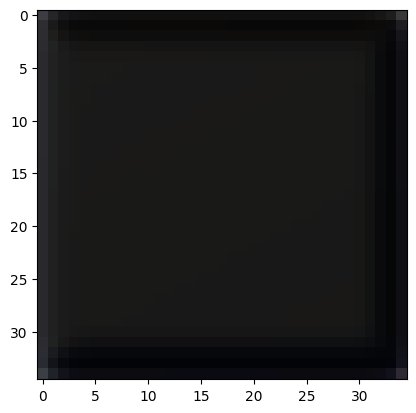

100%|██████████| 300/300 [01:11<00:00,  4.22it/s]

loss: 7361.12158203125, epoch:39/1000


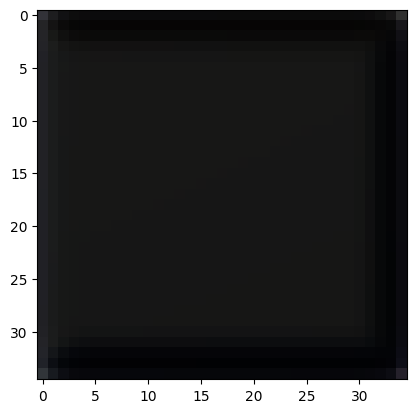

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7361.04736328125, epoch:40/1000


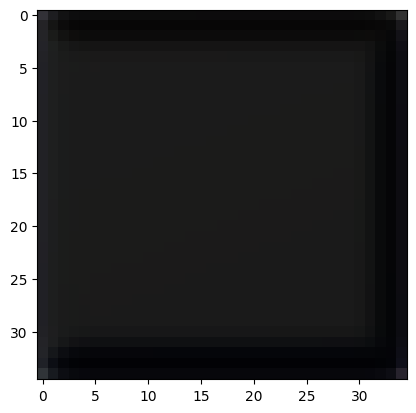

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.98876953125, epoch:41/1000


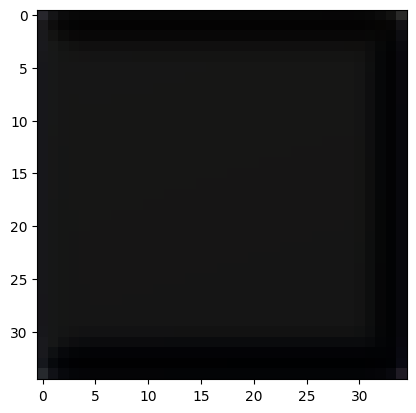

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.94482421875, epoch:42/1000


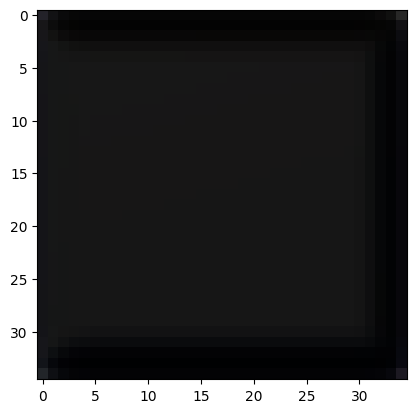

100%|██████████| 300/300 [01:09<00:00,  4.32it/s]

loss: 7360.91650390625, epoch:43/1000


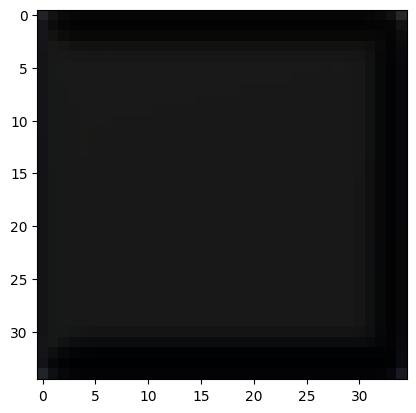

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.89111328125, epoch:44/1000


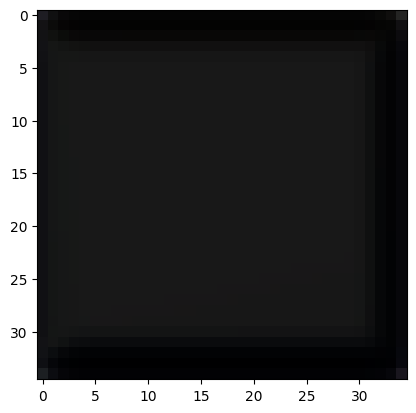

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.8740234375, epoch:45/1000


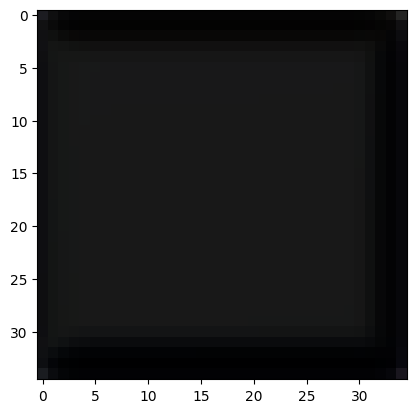

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.85888671875, epoch:46/1000


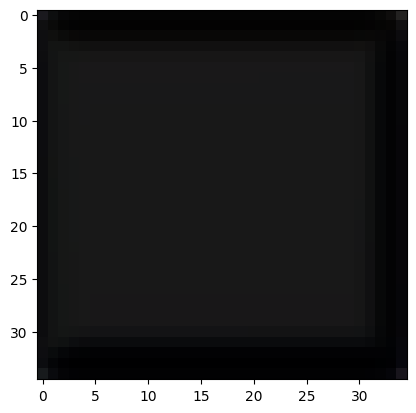

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.84716796875, epoch:47/1000


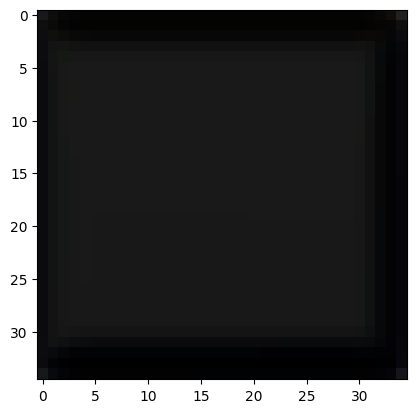

100%|██████████| 300/300 [01:09<00:00,  4.32it/s]

loss: 7360.8544921875, epoch:48/1000


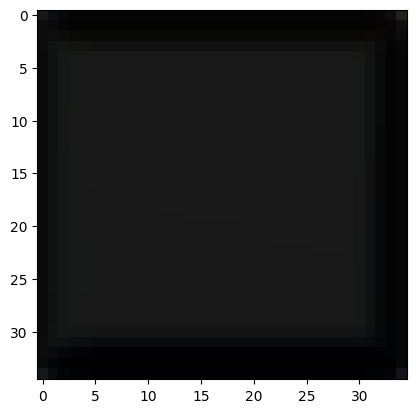

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.8330078125, epoch:49/1000


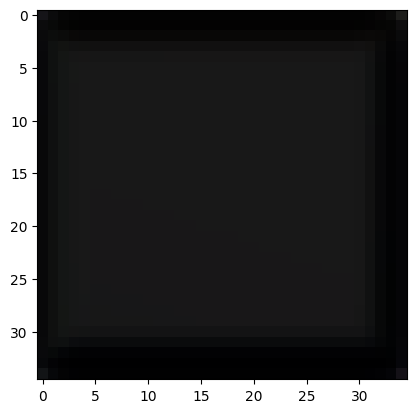

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.82421875, epoch:50/1000


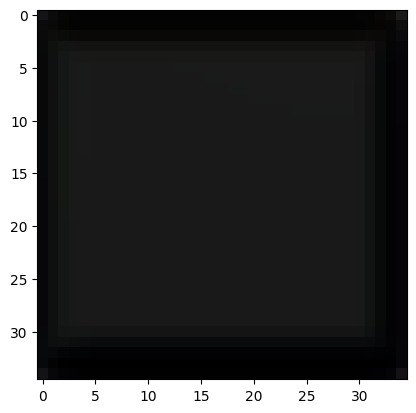

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.81689453125, epoch:51/1000


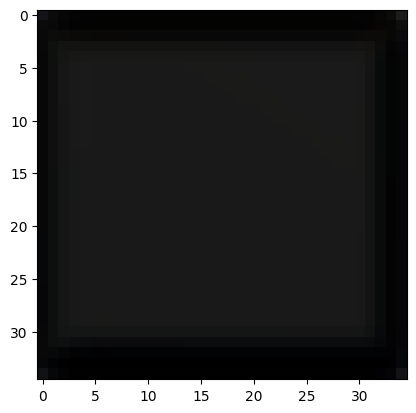

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.802734375, epoch:52/1000


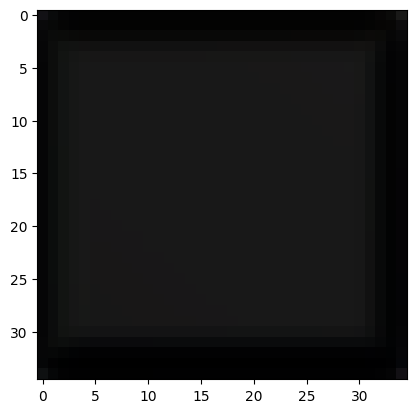

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.79833984375, epoch:53/1000


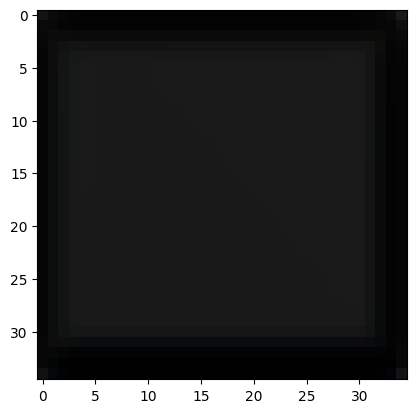

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.9765625, epoch:54/1000


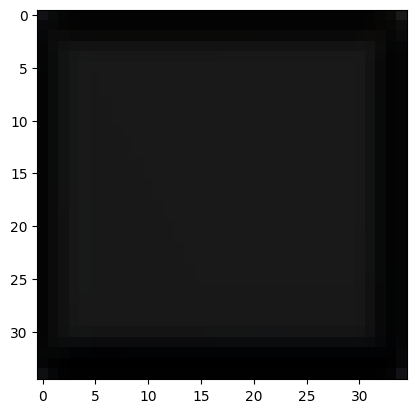

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.79931640625, epoch:55/1000


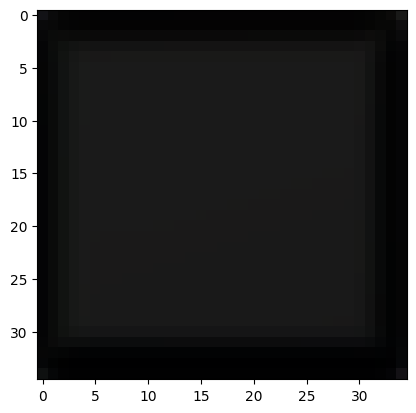

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.794921875, epoch:56/1000


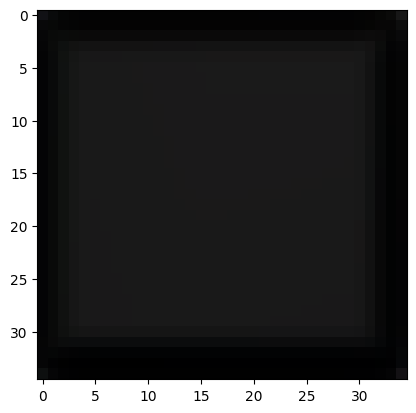

100%|██████████| 300/300 [01:09<00:00,  4.32it/s]

loss: 7360.78857421875, epoch:57/1000


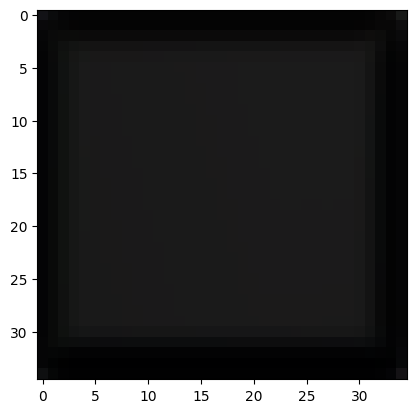

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.787109375, epoch:58/1000


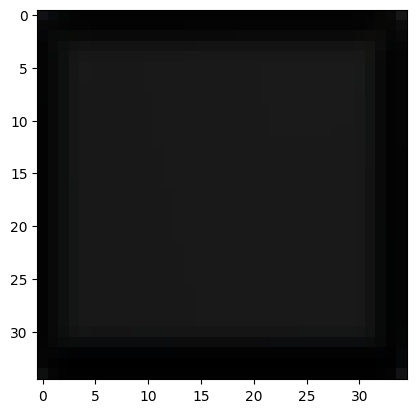

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.78173828125, epoch:59/1000


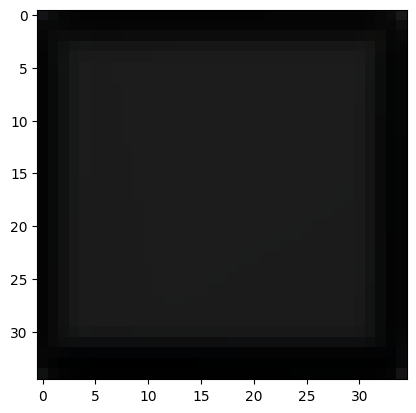

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.77685546875, epoch:60/1000


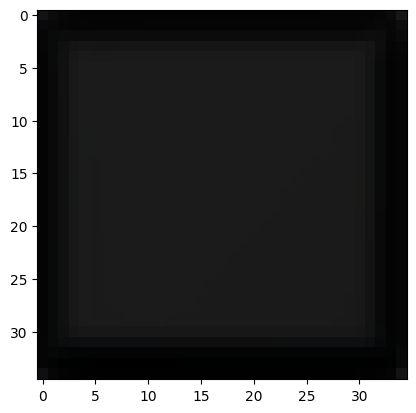

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.77197265625, epoch:61/1000


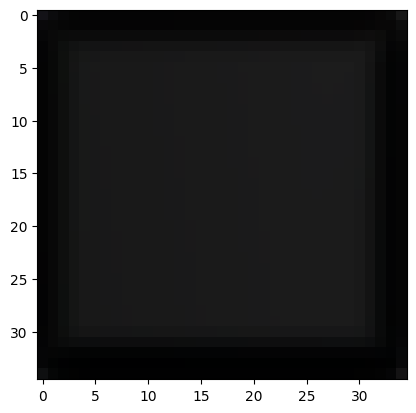

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.76171875, epoch:62/1000


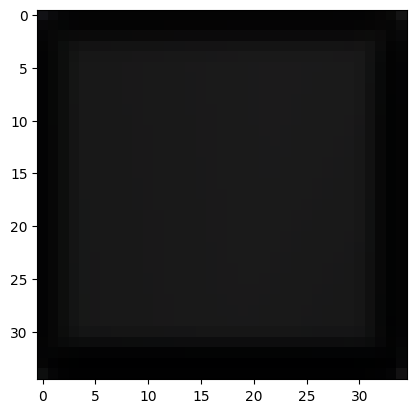

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.74951171875, epoch:63/1000


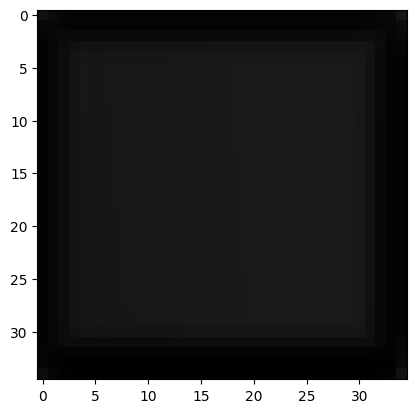

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.73583984375, epoch:64/1000


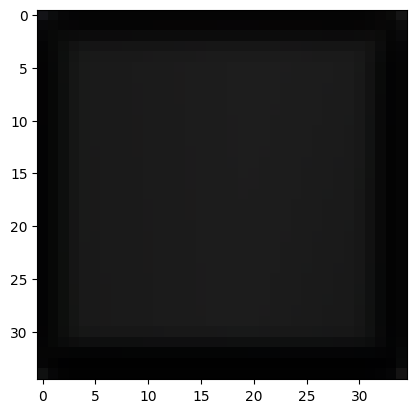

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.72265625, epoch:65/1000


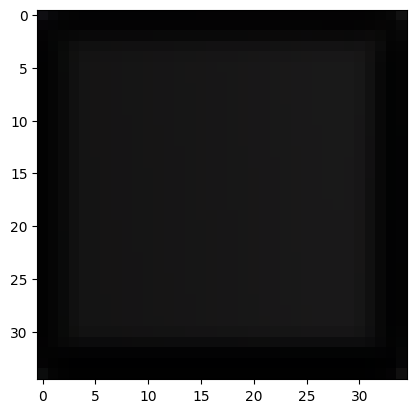

100%|██████████| 300/300 [01:09<00:00,  4.33it/s]

loss: 7360.70947265625, epoch:66/1000


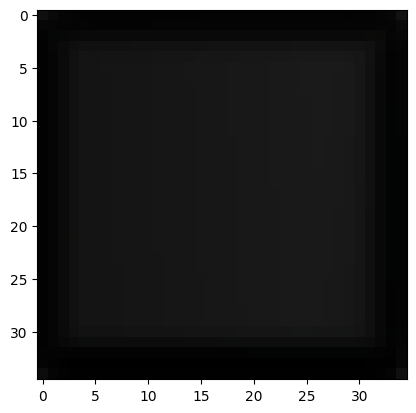

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.6904296875, epoch:67/1000


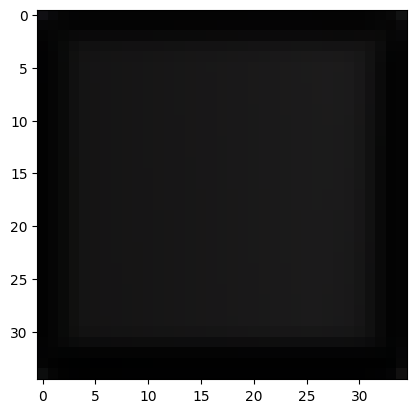

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.67333984375, epoch:68/1000


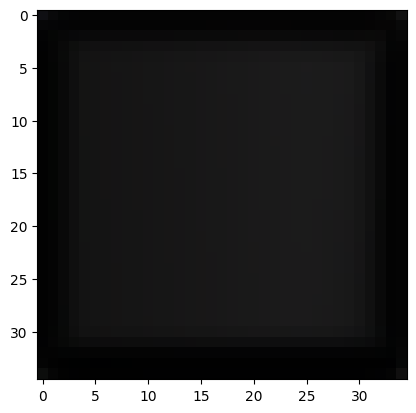

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.65673828125, epoch:69/1000


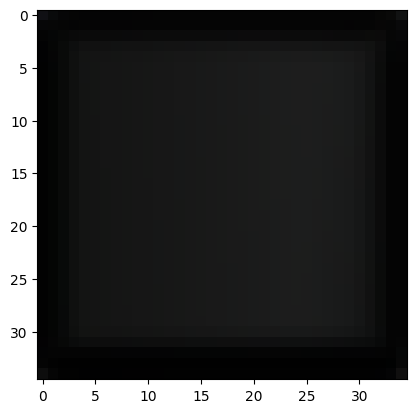

100%|██████████| 300/300 [01:10<00:00,  4.23it/s]

loss: 7360.6416015625, epoch:70/1000


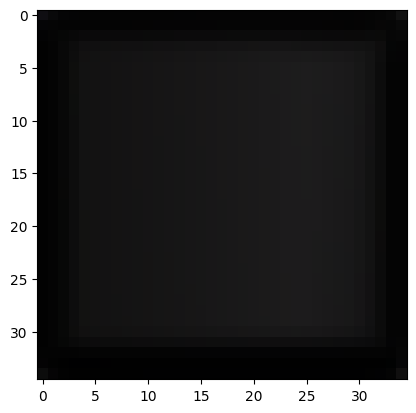

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.619140625, epoch:71/1000


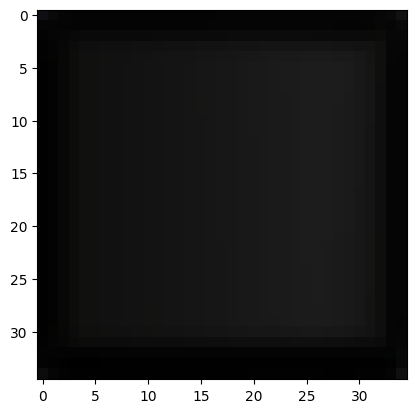

100%|██████████| 300/300 [01:10<00:00,  4.29it/s]

loss: 7360.6005859375, epoch:72/1000


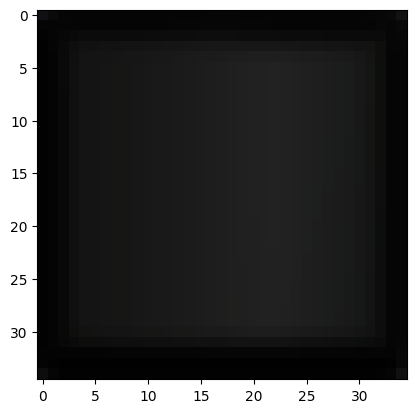

100%|██████████| 300/300 [01:09<00:00,  4.32it/s]

loss: 7360.576171875, epoch:73/1000


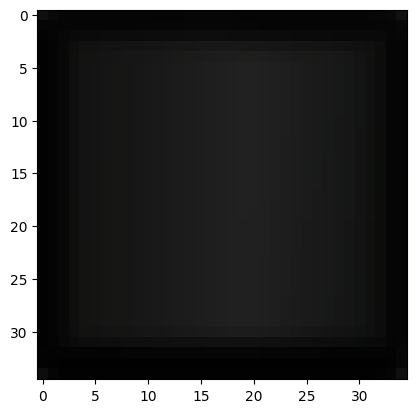

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.53271484375, epoch:74/1000


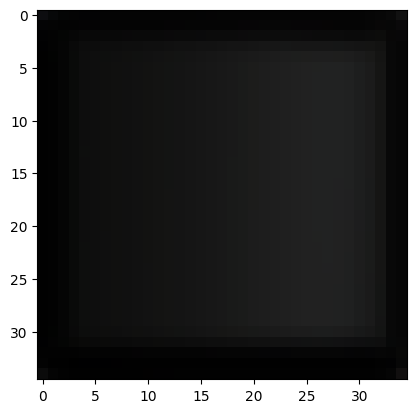

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.49169921875, epoch:75/1000


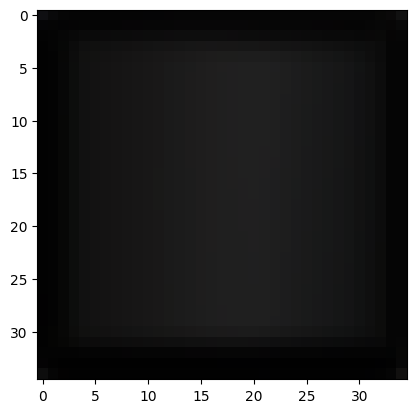

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.4619140625, epoch:76/1000


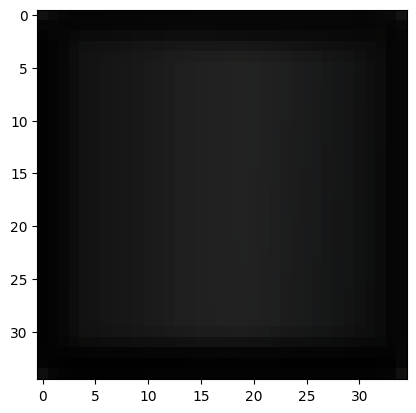

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.4423828125, epoch:77/1000


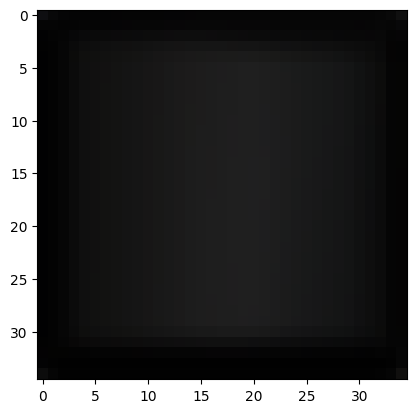

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.4296875, epoch:78/1000


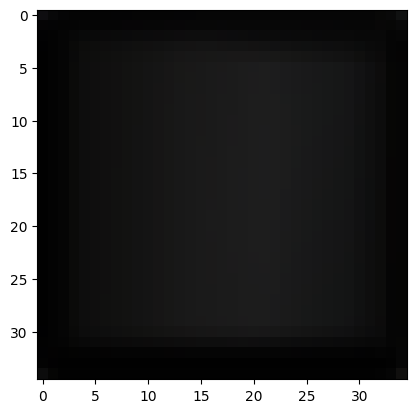

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.4111328125, epoch:79/1000


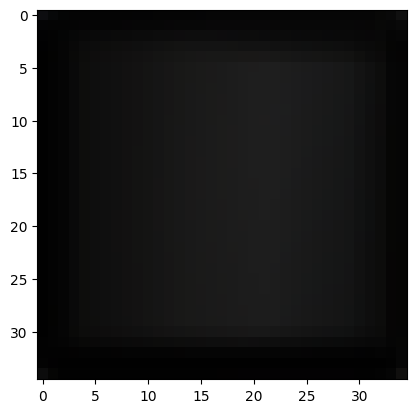

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.40087890625, epoch:80/1000


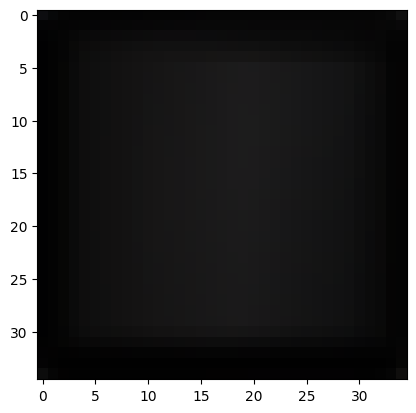

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7360.39306640625, epoch:81/1000


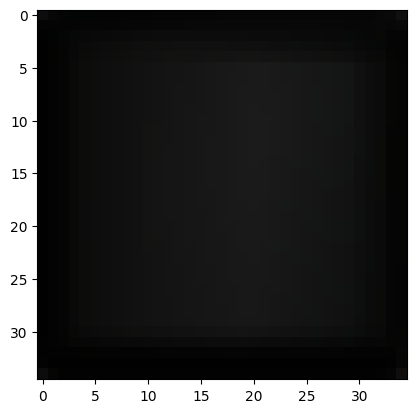

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7360.38330078125, epoch:82/1000


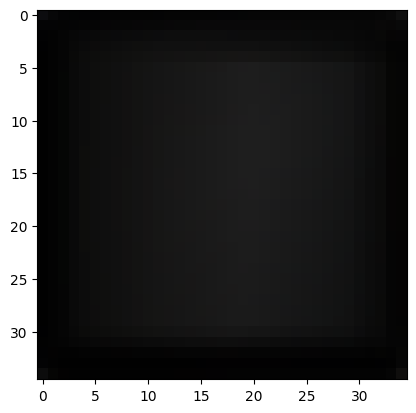

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]


loss: 7360.375, epoch:83/1000


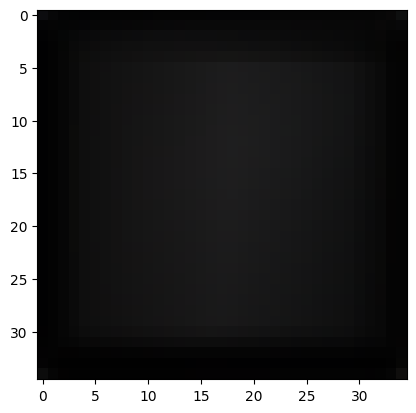

100%|██████████| 300/300 [01:10<00:00,  4.29it/s]

loss: 7360.36181640625, epoch:84/1000


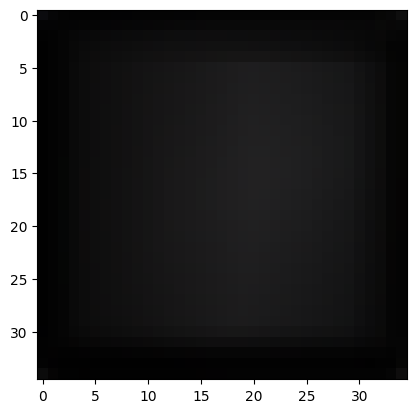

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]


loss: 7360.328125, epoch:85/1000


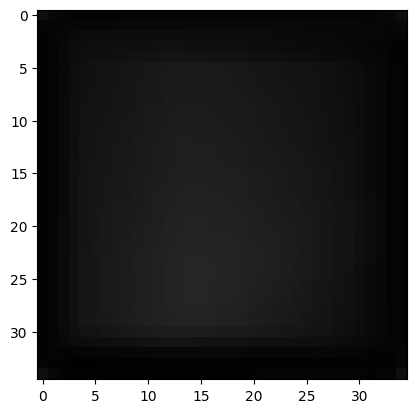

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.22021484375, epoch:86/1000


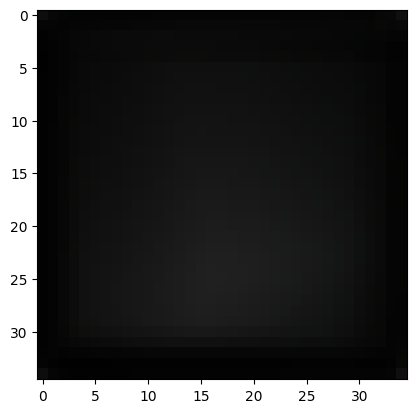

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.16259765625, epoch:87/1000


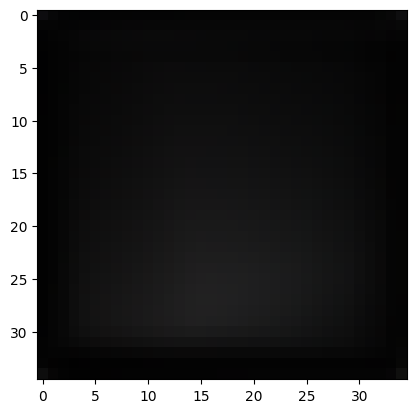

100%|██████████| 300/300 [01:11<00:00,  4.20it/s]

loss: 7360.130859375, epoch:88/1000


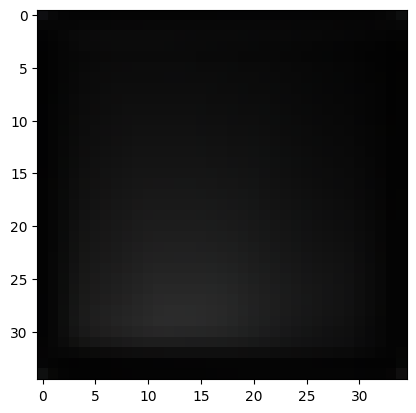

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.10693359375, epoch:89/1000


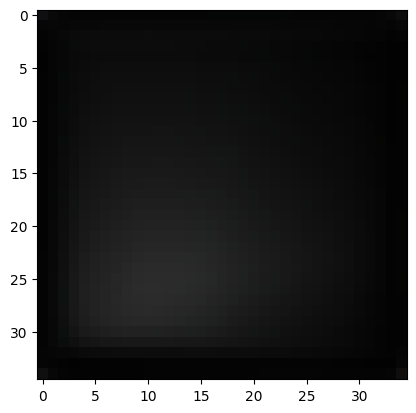

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7360.09130859375, epoch:90/1000


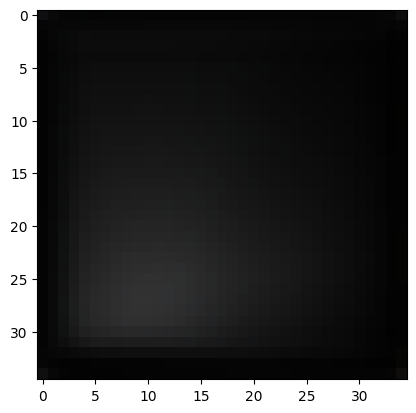

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.07666015625, epoch:91/1000


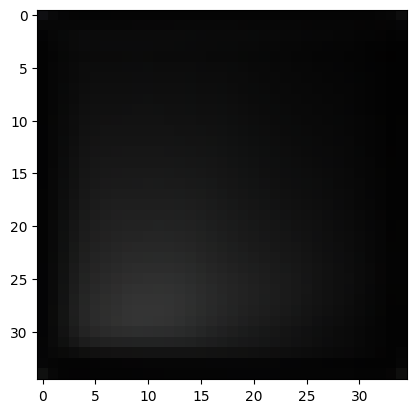

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.06005859375, epoch:92/1000


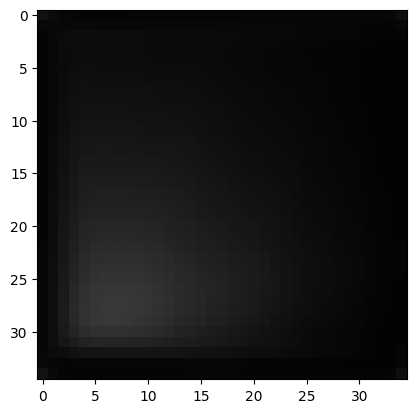

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.07421875, epoch:93/1000


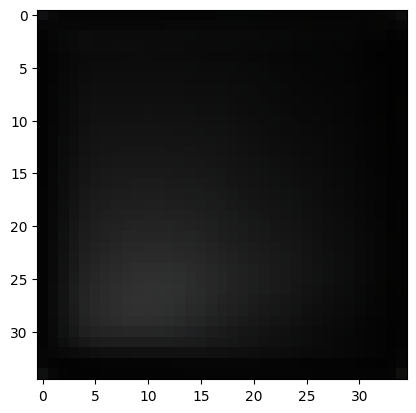

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.0576171875, epoch:94/1000


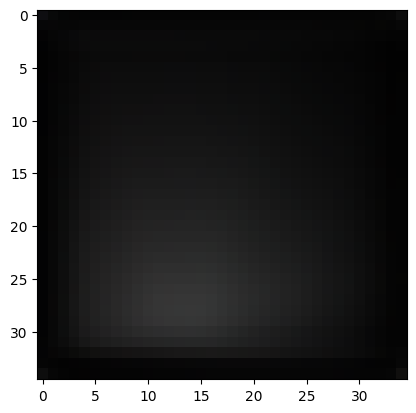

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.19677734375, epoch:95/1000


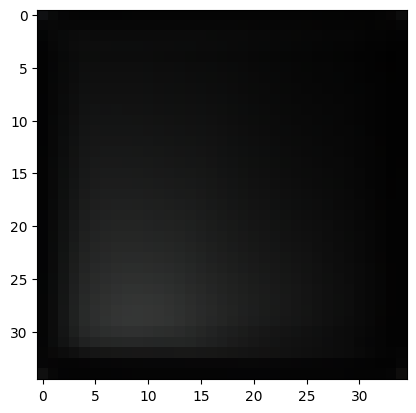

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.1279296875, epoch:96/1000


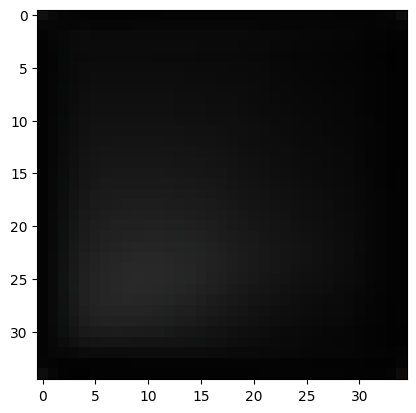

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7360.1240234375, epoch:97/1000


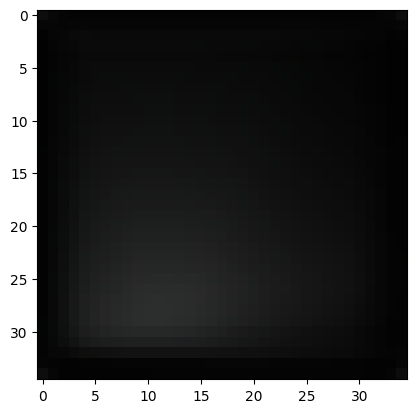

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7366.626953125, epoch:98/1000


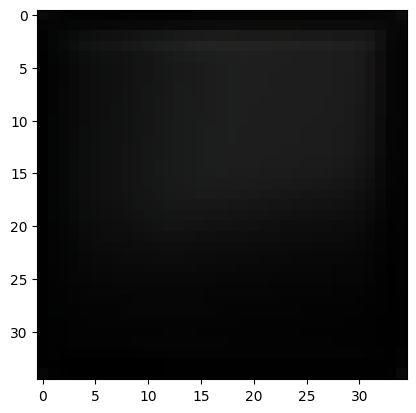

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7361.29296875, epoch:99/1000


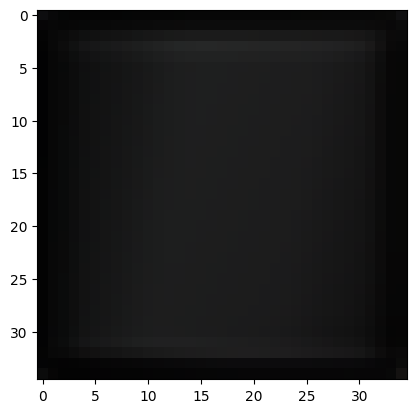

100%|██████████| 300/300 [01:10<00:00,  4.24it/s]

loss: 7362.96923828125, epoch:100/1000


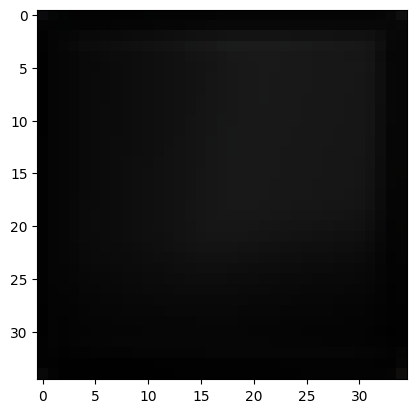

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7361.69189453125, epoch:101/1000


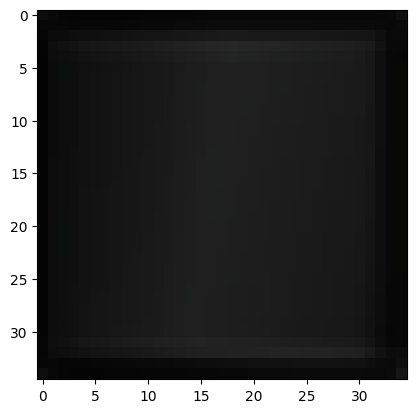

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7363.00390625, epoch:102/1000


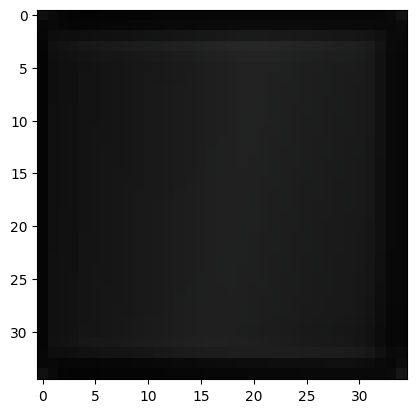

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7359.68896484375, epoch:103/1000


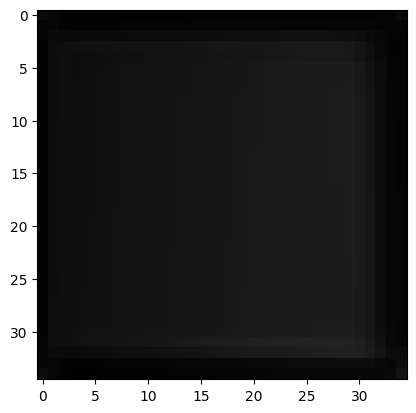

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.865234375, epoch:104/1000


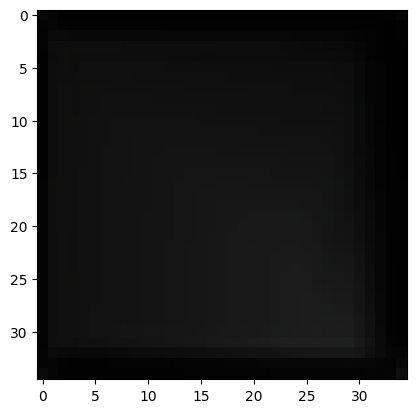

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.814453125, epoch:105/1000


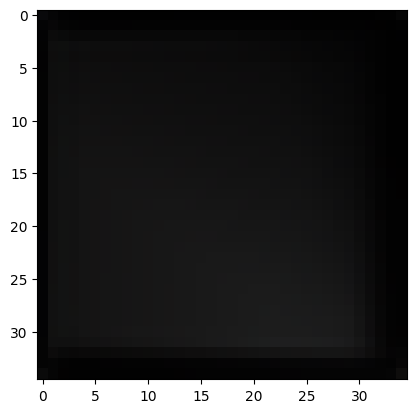

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.81005859375, epoch:106/1000


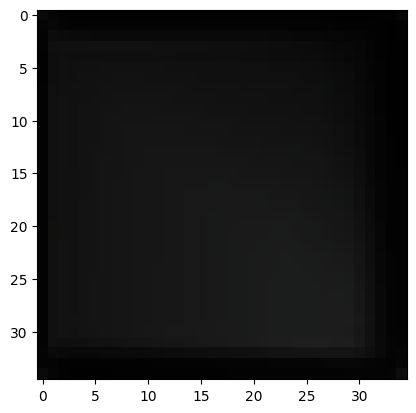

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.796875, epoch:107/1000


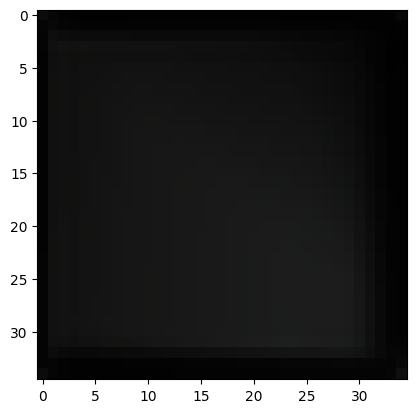

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.78662109375, epoch:108/1000


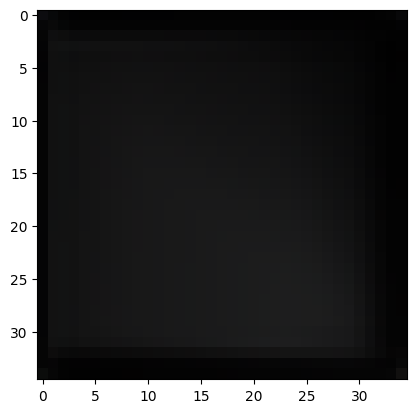

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.7822265625, epoch:109/1000


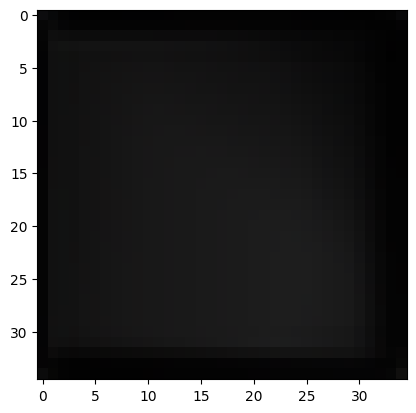

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.77197265625, epoch:110/1000


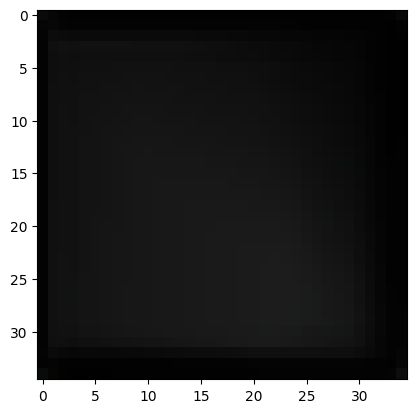

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.72021484375, epoch:111/1000


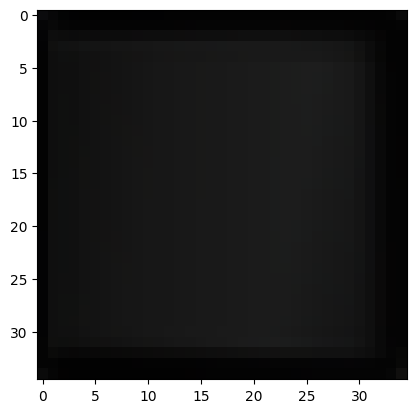

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.76416015625, epoch:112/1000


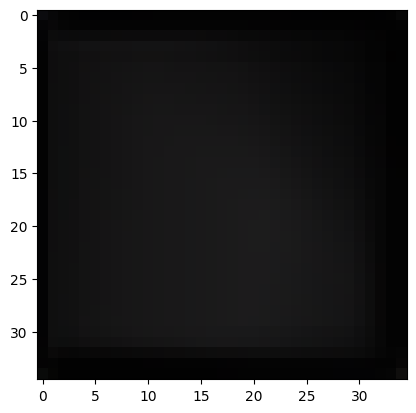

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7360.77734375, epoch:113/1000


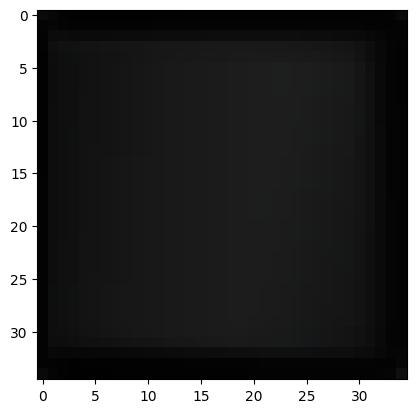

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.7509765625, epoch:114/1000


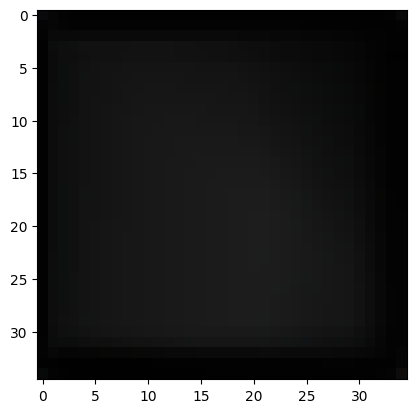

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7361.1357421875, epoch:115/1000


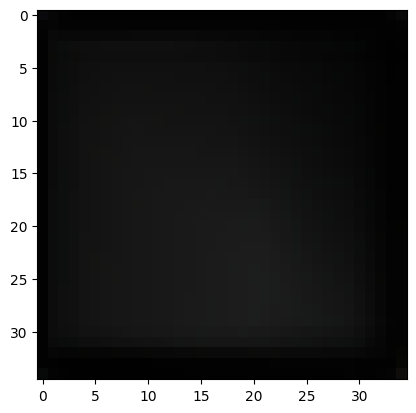

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7360.83154296875, epoch:116/1000


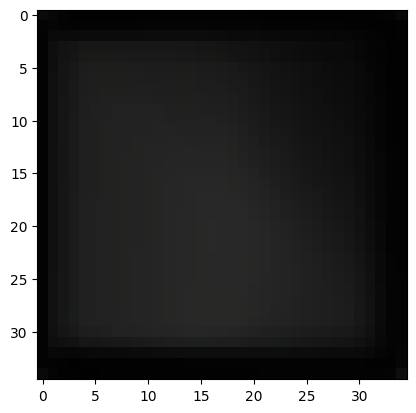

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7359.11279296875, epoch:117/1000


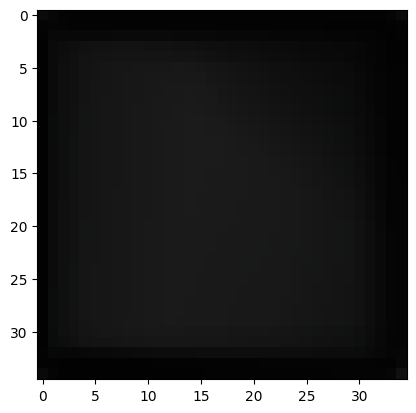

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.7509765625, epoch:118/1000


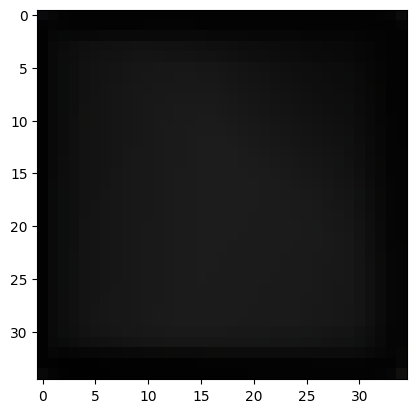

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.73974609375, epoch:119/1000


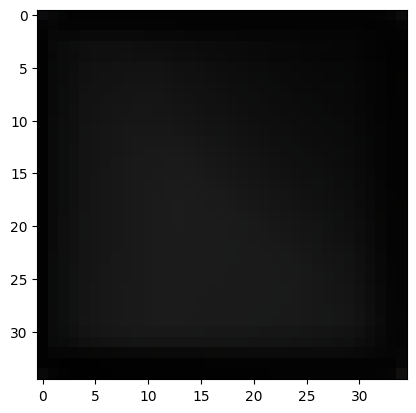

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.7373046875, epoch:120/1000


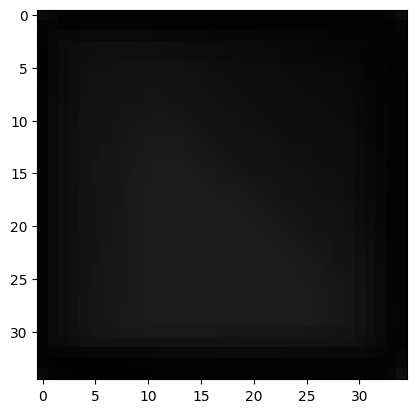

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.72705078125, epoch:121/1000


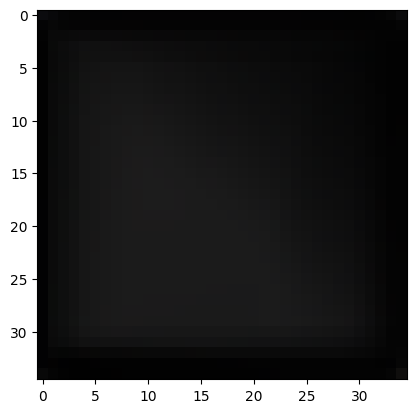

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.71923828125, epoch:122/1000


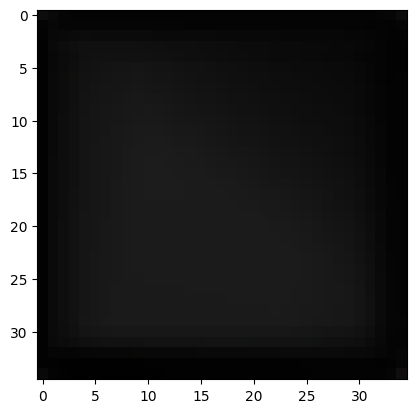

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.63623046875, epoch:123/1000


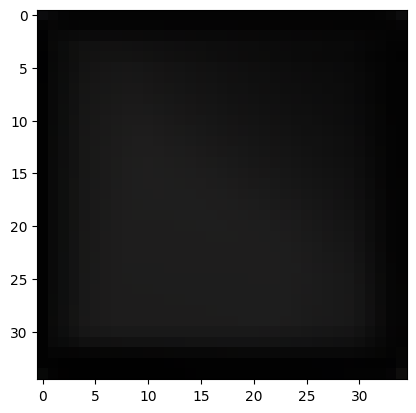

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.71044921875, epoch:124/1000


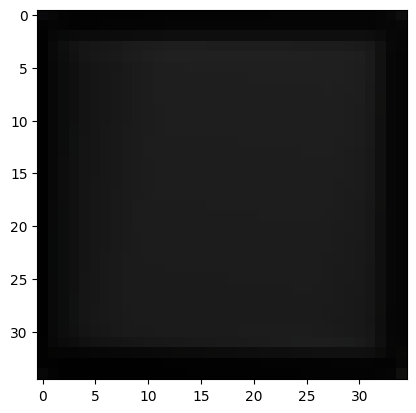

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.75, epoch:125/1000


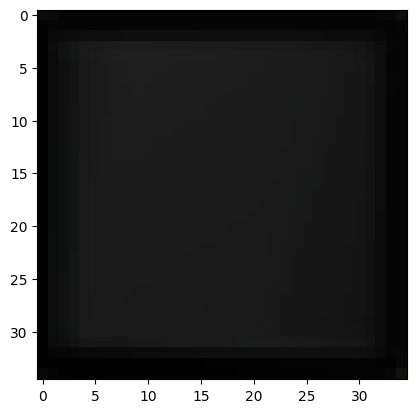

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.734375, epoch:126/1000


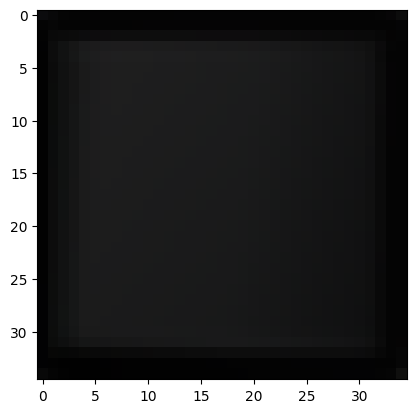

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.73193359375, epoch:127/1000


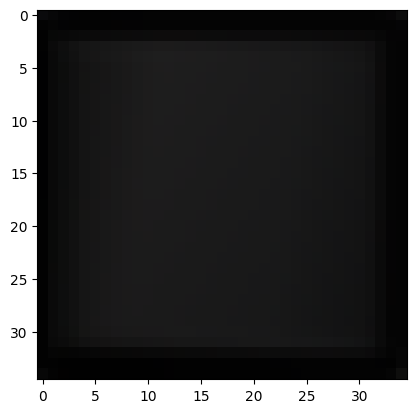

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.72607421875, epoch:128/1000


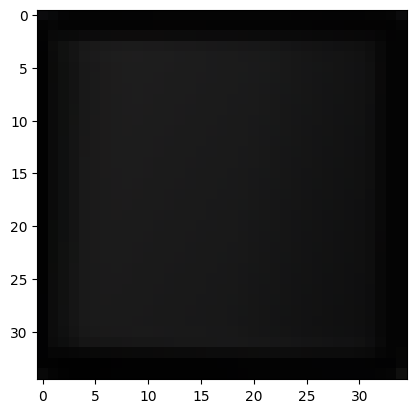

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.7216796875, epoch:129/1000


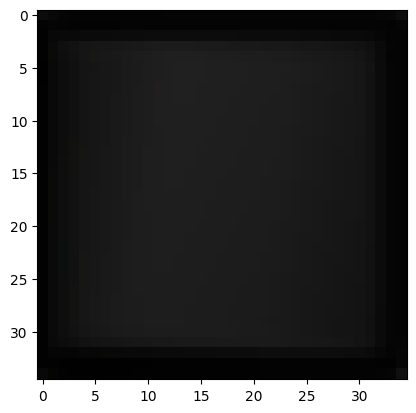

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.71923828125, epoch:130/1000


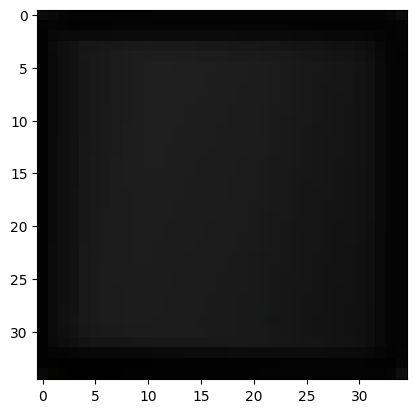

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7360.70947265625, epoch:131/1000


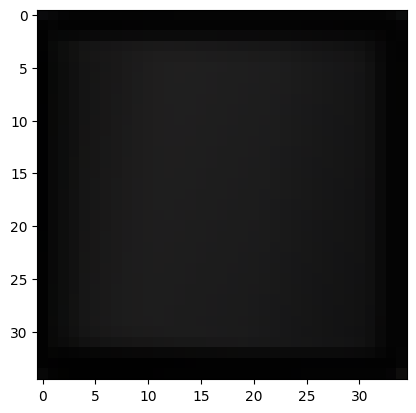

100%|██████████| 300/300 [01:10<00:00,  4.29it/s]

loss: 7360.7021484375, epoch:132/1000


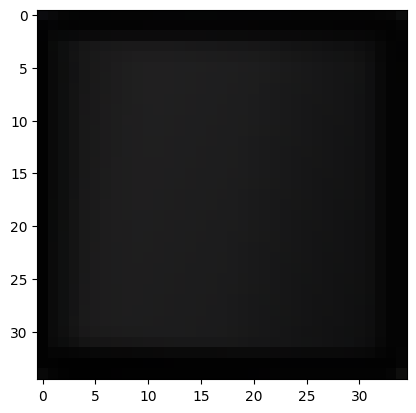

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.69287109375, epoch:133/1000


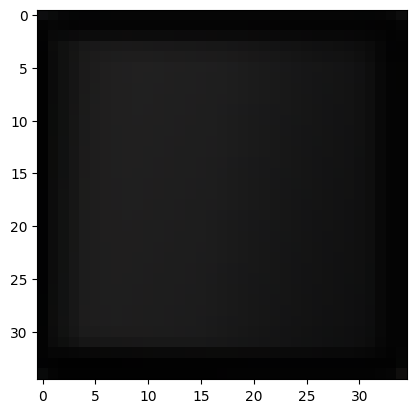

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7360.6875, epoch:134/1000


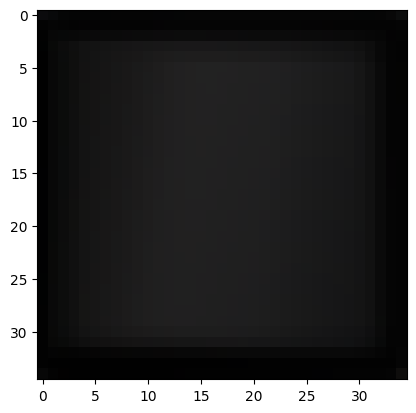

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.67333984375, epoch:135/1000


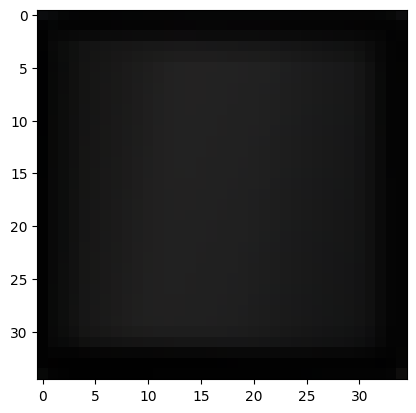

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.66650390625, epoch:136/1000


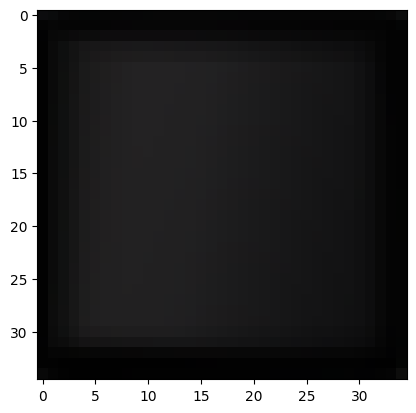

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.65625, epoch:137/1000


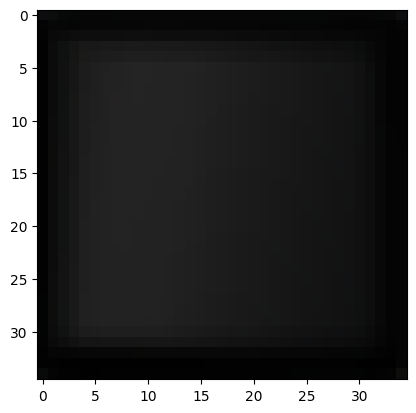

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]


loss: 7360.63671875, epoch:138/1000


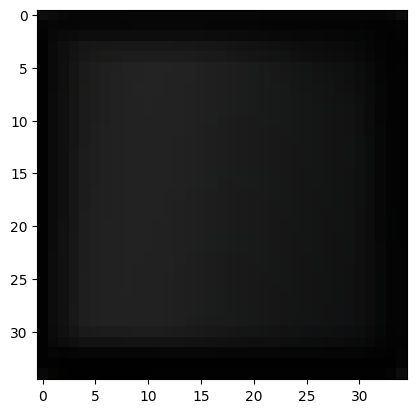

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]


loss: 7360.5908203125, epoch:139/1000


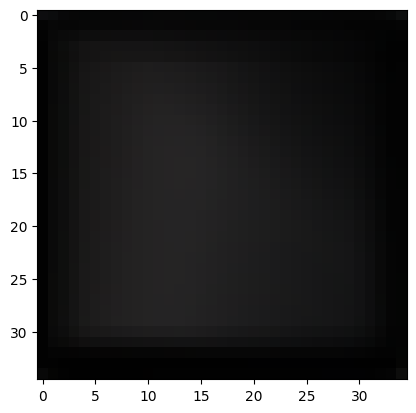

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.5791015625, epoch:140/1000


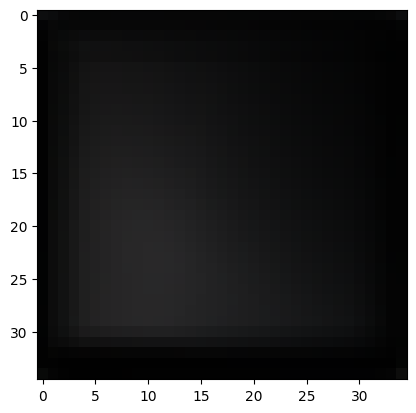

100%|██████████| 300/300 [01:10<00:00,  4.24it/s]

loss: 7360.544921875, epoch:141/1000


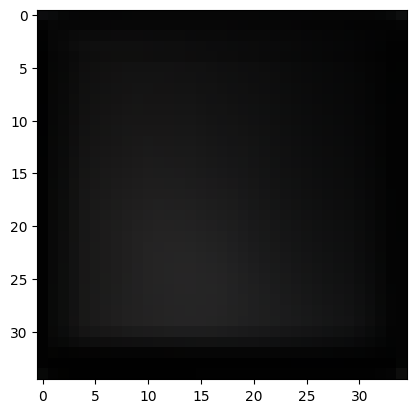

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]


loss: 7360.54541015625, epoch:142/1000


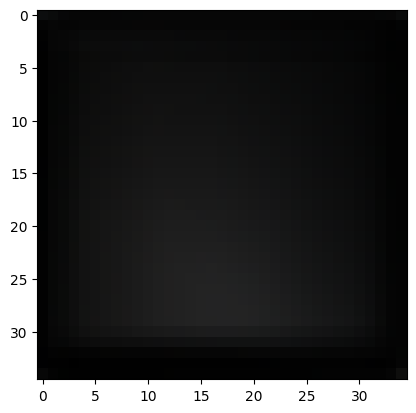

100%|██████████| 300/300 [01:11<00:00,  4.21it/s]


loss: 7360.5283203125, epoch:143/1000


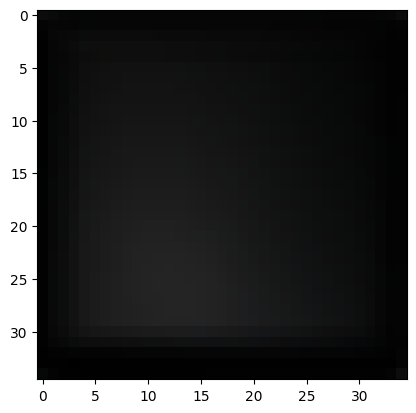

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.4736328125, epoch:144/1000


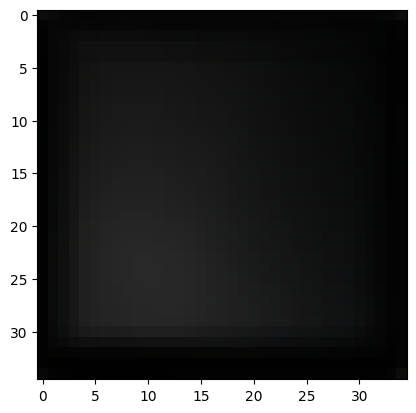

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7359.93603515625, epoch:145/1000


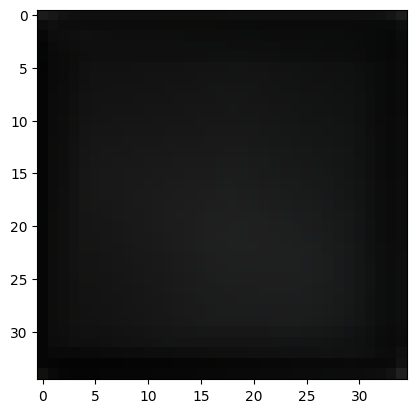

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7361.037109375, epoch:146/1000


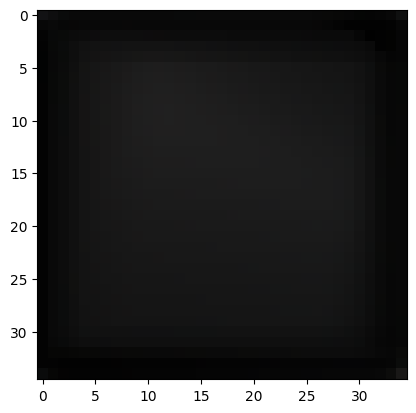

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.06396484375, epoch:147/1000


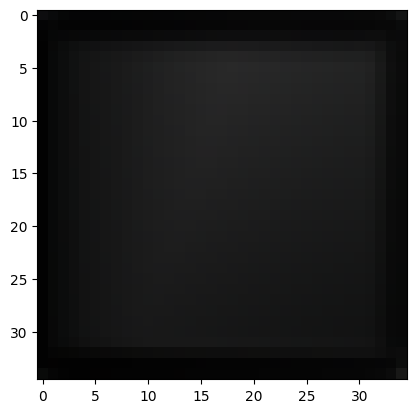

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.7587890625, epoch:148/1000


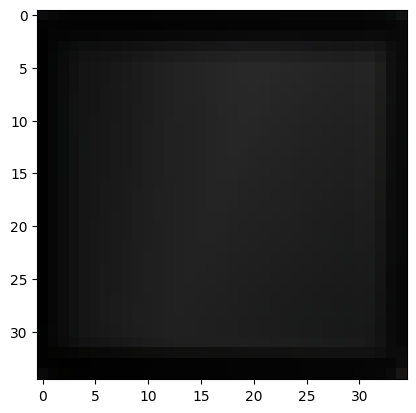

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7360.7451171875, epoch:149/1000


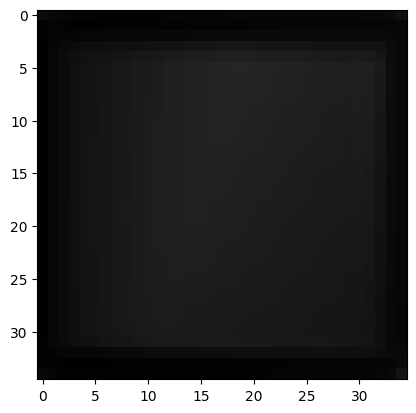

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.97265625, epoch:150/1000


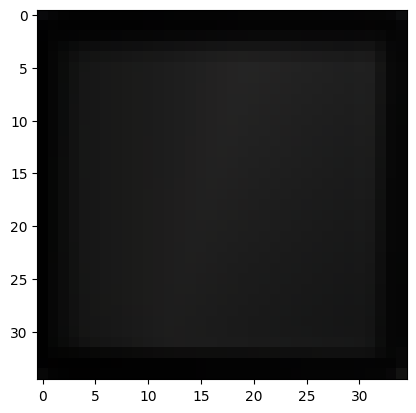

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.52783203125, epoch:151/1000


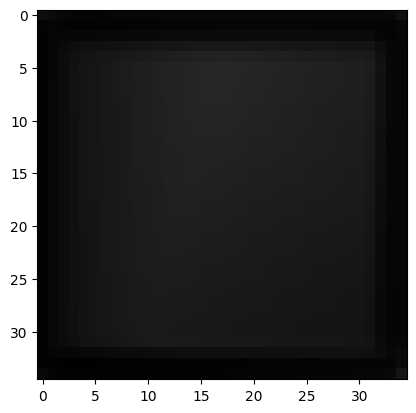

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.76171875, epoch:152/1000


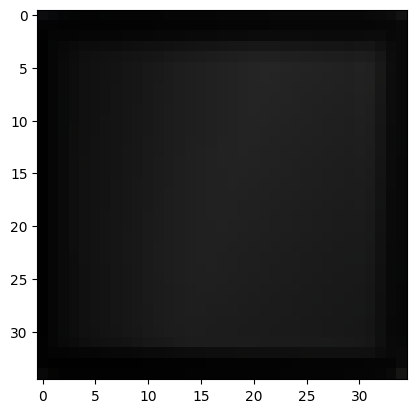

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.771484375, epoch:153/1000


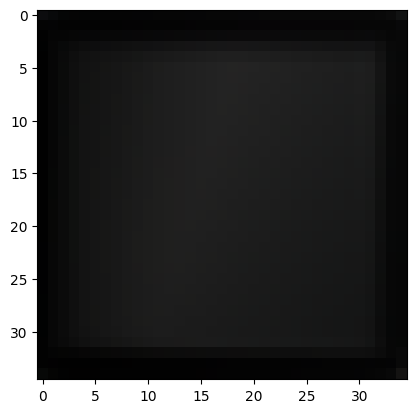

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]


loss: 7360.748046875, epoch:154/1000


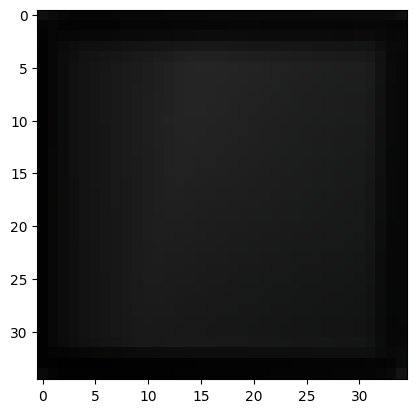

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7359.7548828125, epoch:155/1000


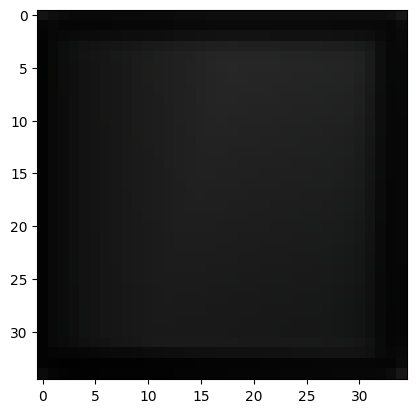

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.857421875, epoch:156/1000


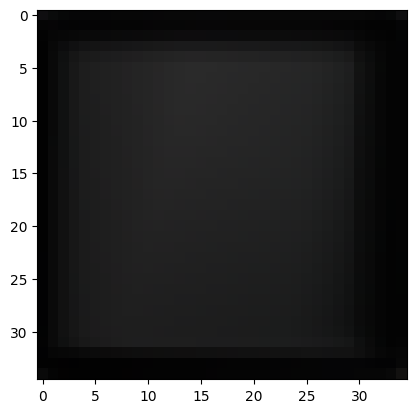

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7359.974609375, epoch:157/1000


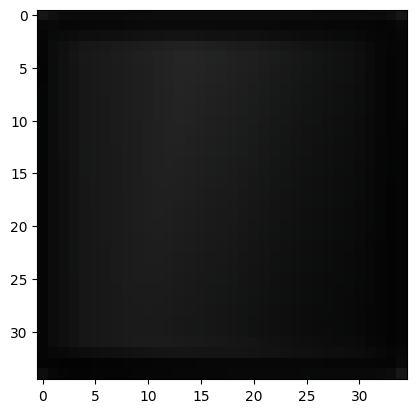

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7361.60791015625, epoch:158/1000


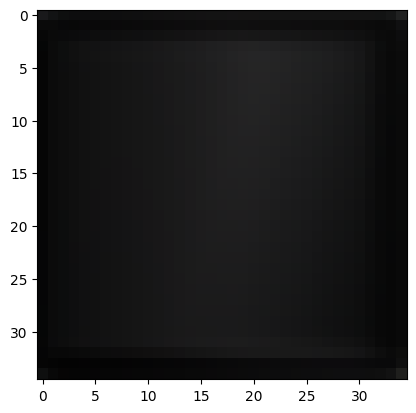

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7359.1591796875, epoch:159/1000


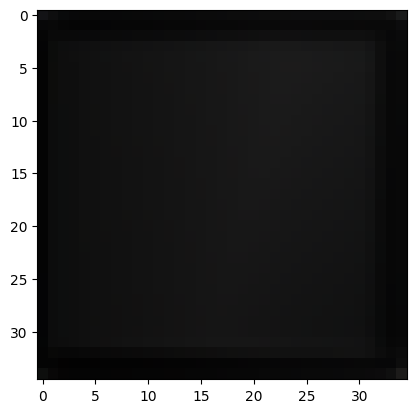

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7358.72607421875, epoch:160/1000


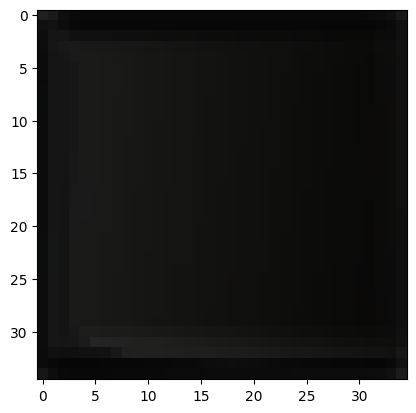

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7361.443359375, epoch:161/1000


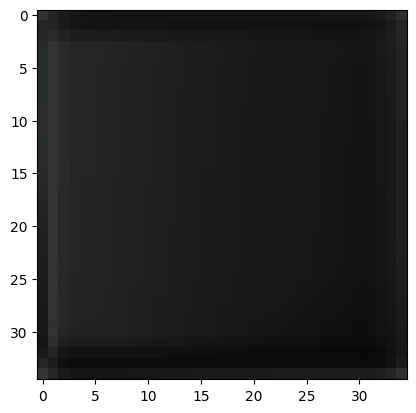

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7358.53662109375, epoch:162/1000


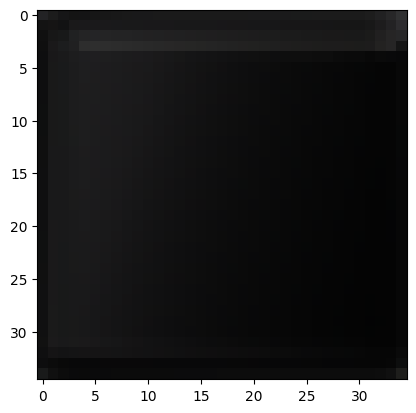

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.14306640625, epoch:163/1000


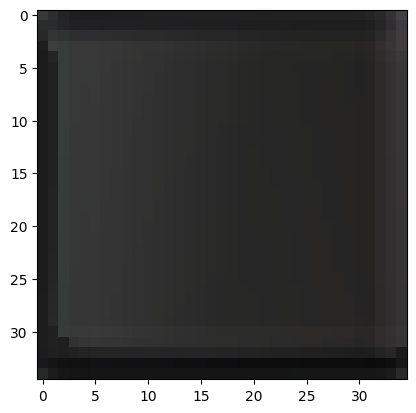

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7361.5263671875, epoch:164/1000


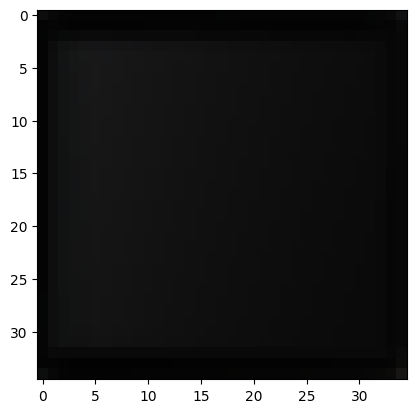

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7361.16162109375, epoch:165/1000


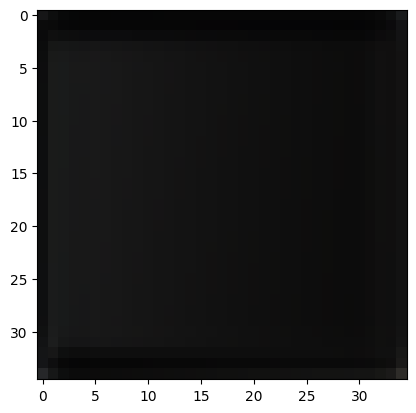

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7360.81298828125, epoch:166/1000


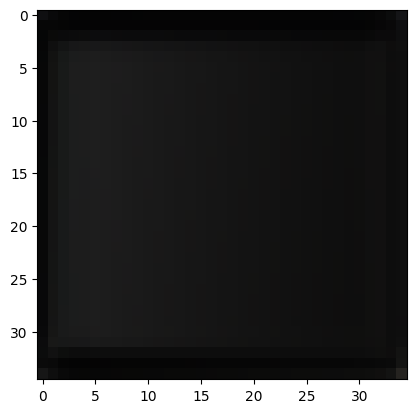

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7361.28076171875, epoch:167/1000


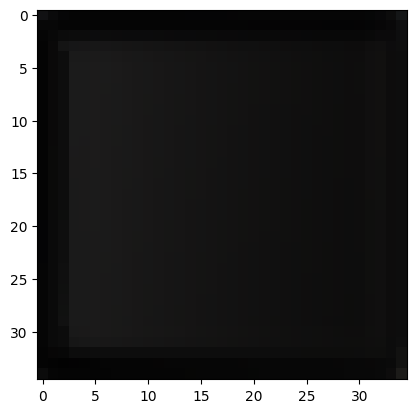

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7358.6455078125, epoch:168/1000


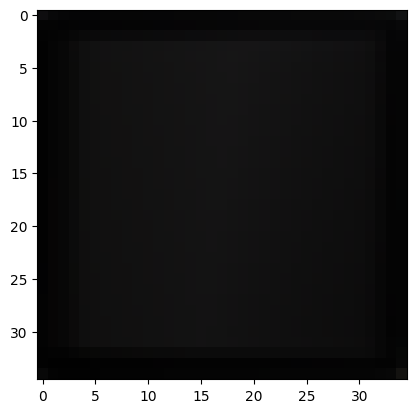

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7361.48291015625, epoch:169/1000


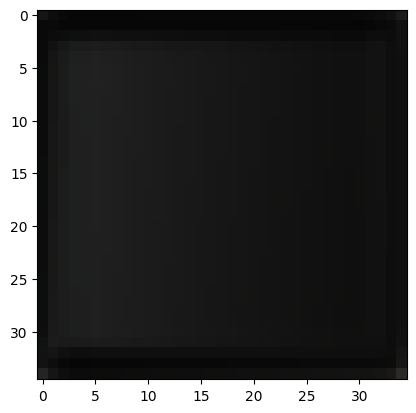

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]


loss: 7360.01513671875, epoch:170/1000


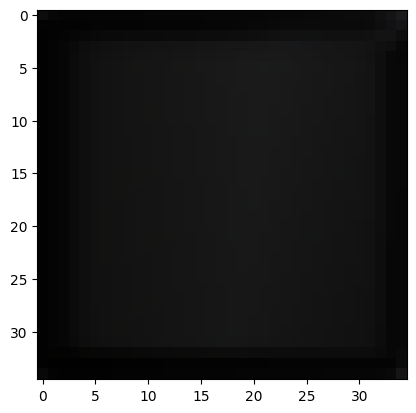

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7361.1015625, epoch:171/1000


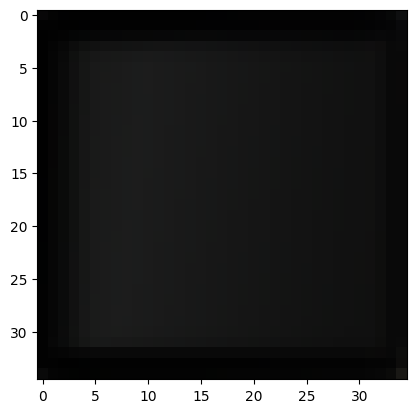

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7359.5517578125, epoch:172/1000


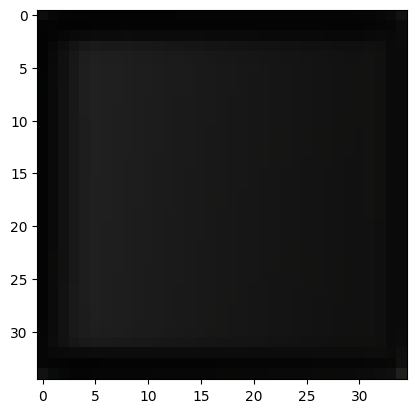

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7357.49658203125, epoch:173/1000


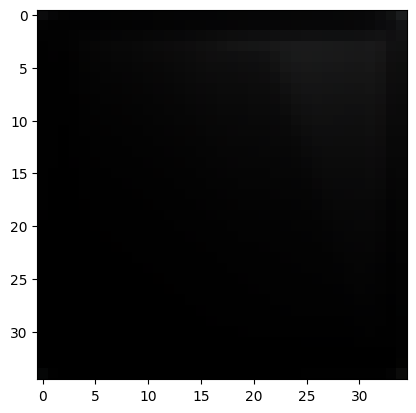

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7362.4091796875, epoch:174/1000


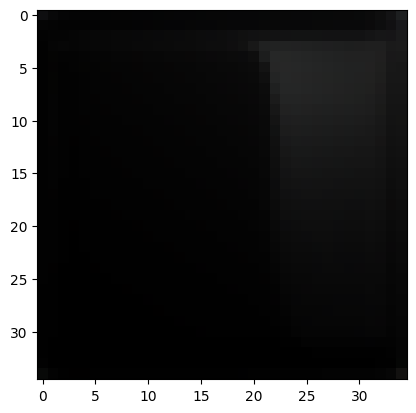

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7361.40966796875, epoch:175/1000


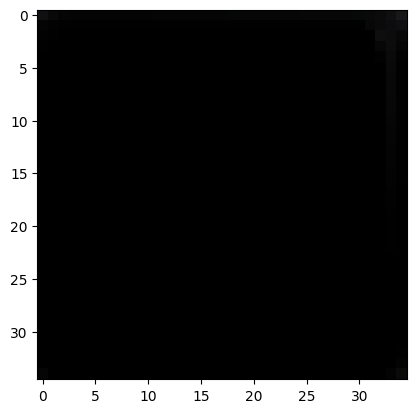

100%|██████████| 300/300 [01:10<00:00,  4.23it/s]

loss: 7360.76220703125, epoch:176/1000


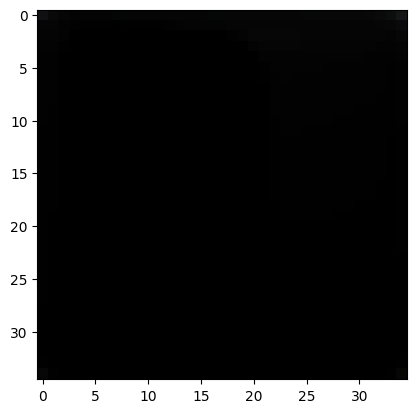

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7361.19140625, epoch:177/1000


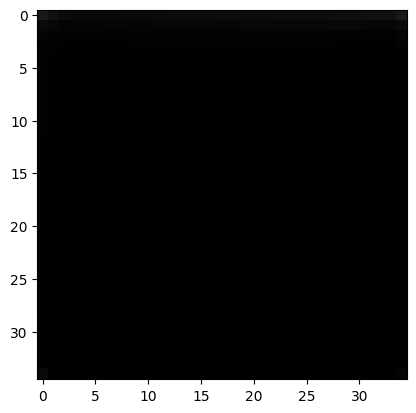

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.66162109375, epoch:178/1000


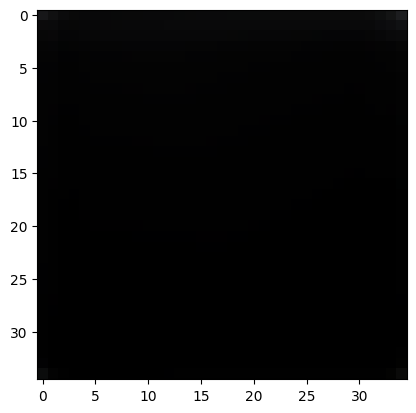

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7359.0478515625, epoch:179/1000


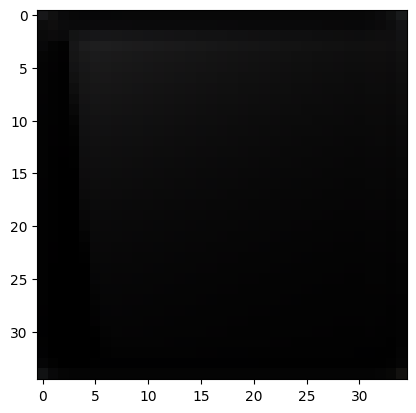

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7361.4814453125, epoch:180/1000


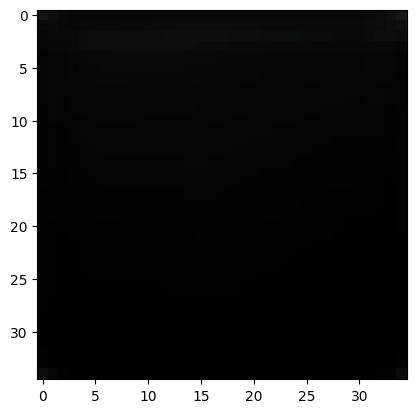

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]


loss: 7356.4453125, epoch:181/1000


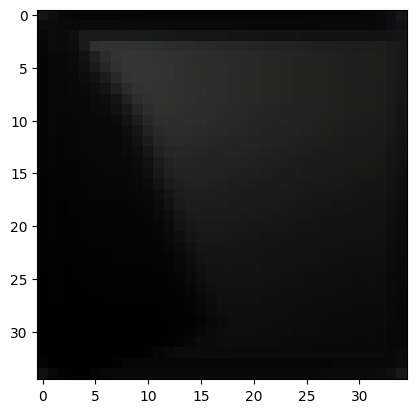

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7362.11572265625, epoch:182/1000


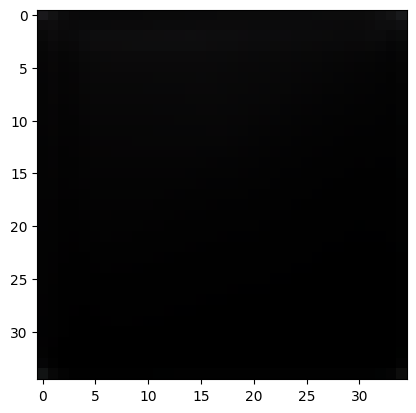

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7361.78955078125, epoch:183/1000


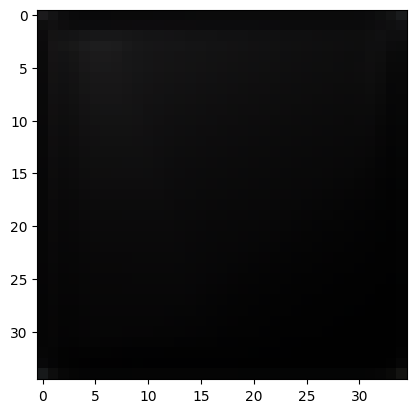

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7356.5419921875, epoch:184/1000


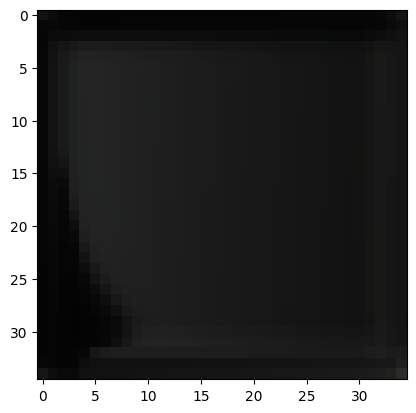

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7359.07958984375, epoch:185/1000


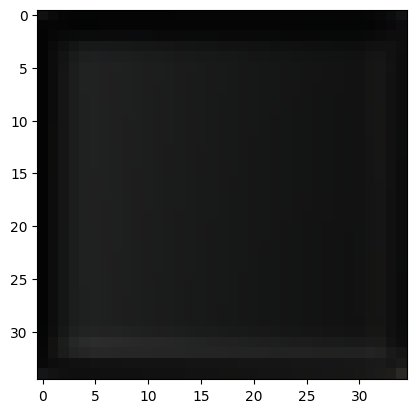

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7361.00927734375, epoch:186/1000


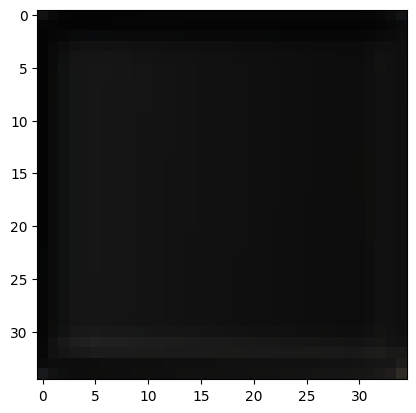

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7359.79296875, epoch:187/1000


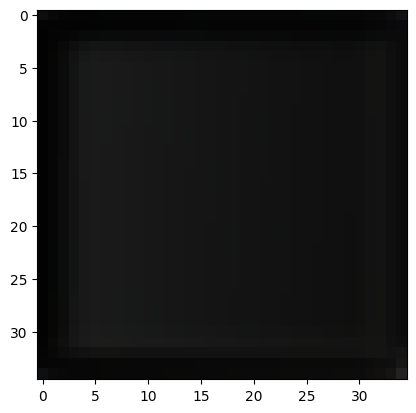

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7361.20849609375, epoch:188/1000


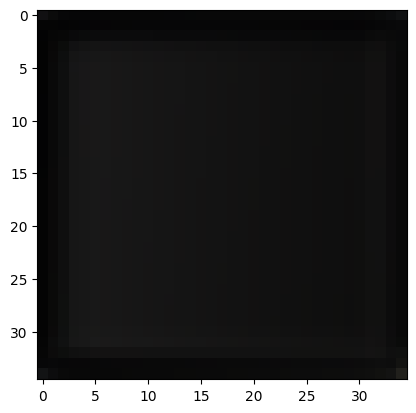

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]


loss: 7361.7666015625, epoch:189/1000


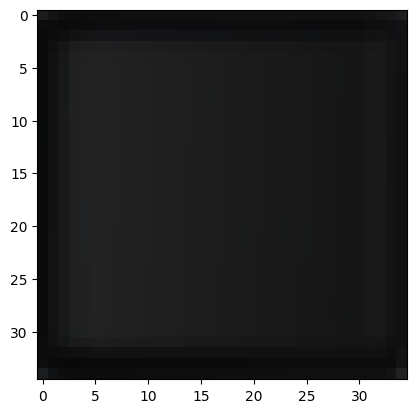

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.9814453125, epoch:190/1000


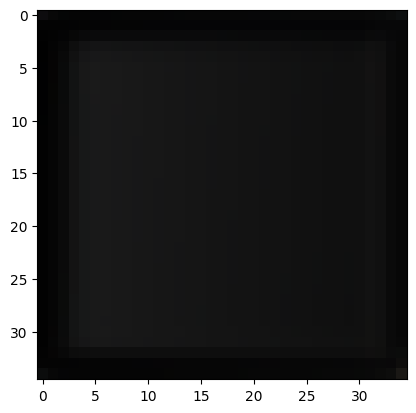

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]


loss: 7360.4599609375, epoch:191/1000


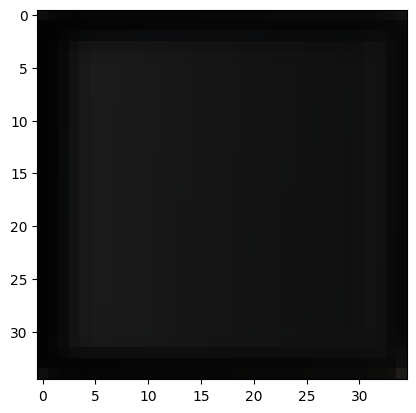

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]


loss: 7360.9091796875, epoch:192/1000


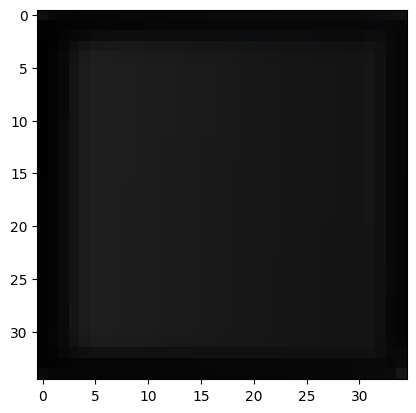

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.89404296875, epoch:193/1000


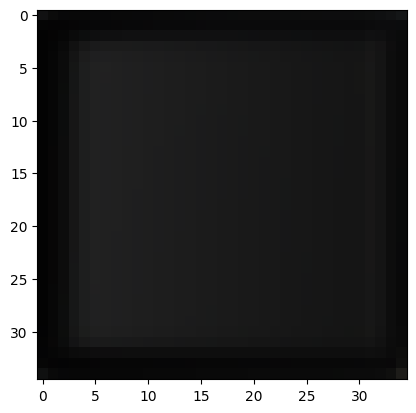

100%|██████████| 300/300 [01:11<00:00,  4.21it/s]

loss: 7360.88427734375, epoch:194/1000


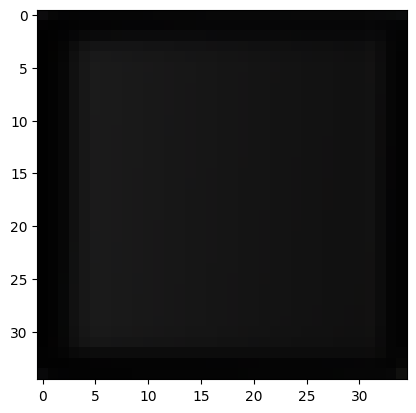

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.876953125, epoch:195/1000


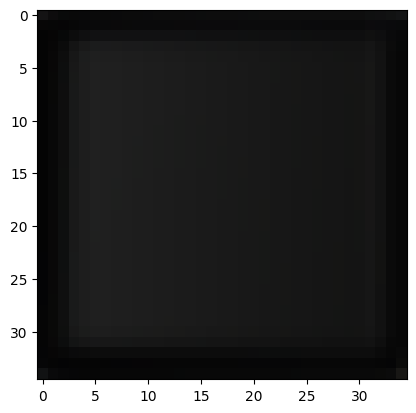

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.59912109375, epoch:196/1000


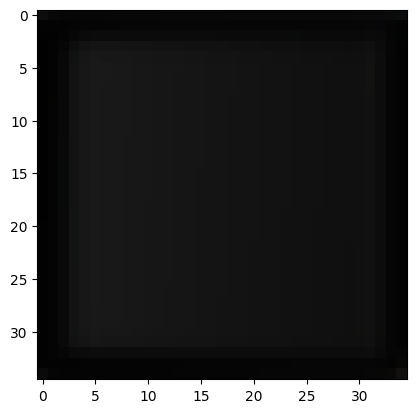

100%|██████████| 300/300 [01:10<00:00,  4.24it/s]


loss: 7360.84619140625, epoch:197/1000


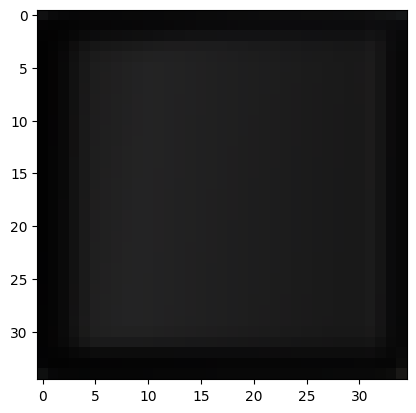

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.8388671875, epoch:198/1000


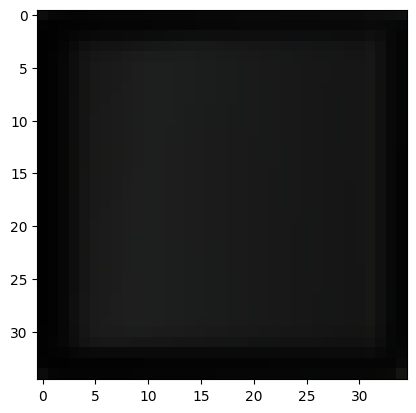

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.833984375, epoch:199/1000


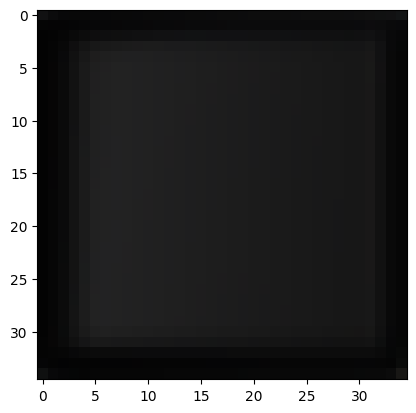

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.02685546875, epoch:200/1000


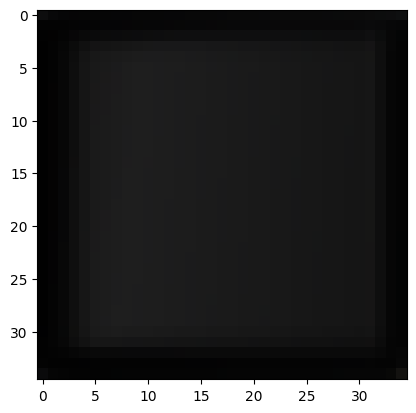

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7360.25048828125, epoch:201/1000


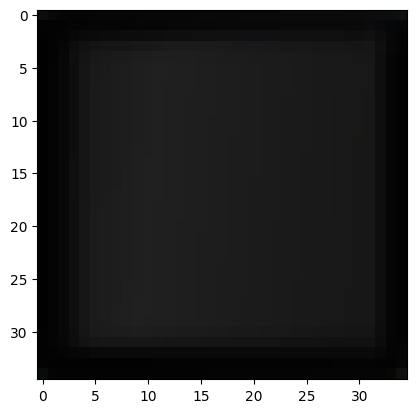

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.806640625, epoch:202/1000


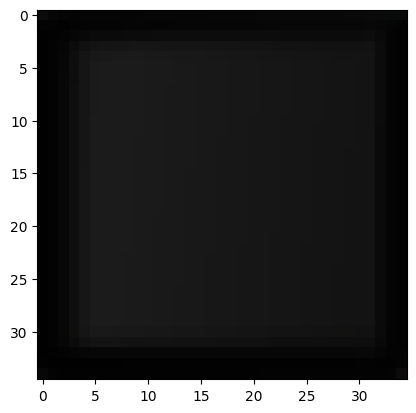

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.79248046875, epoch:203/1000


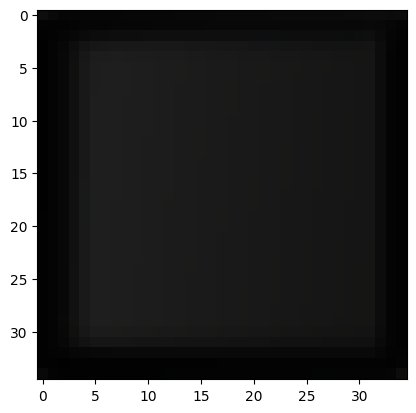

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.72607421875, epoch:204/1000


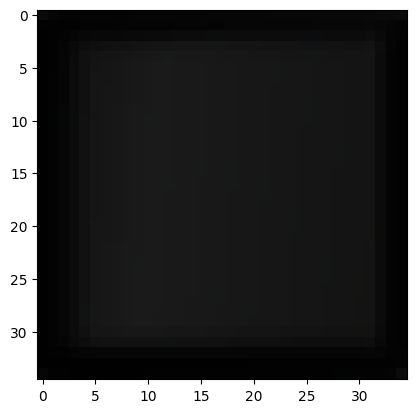

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7359.7822265625, epoch:205/1000


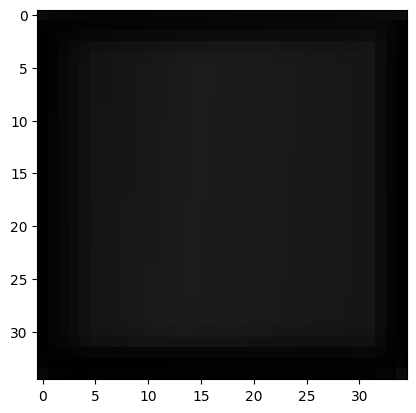

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.68701171875, epoch:206/1000


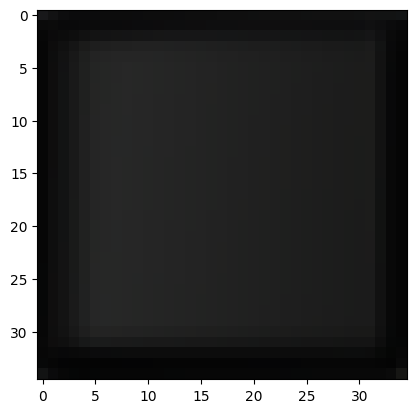

100%|██████████| 300/300 [01:10<00:00,  4.24it/s]

loss: 7360.7998046875, epoch:207/1000


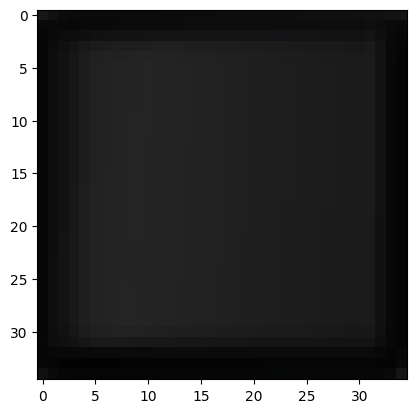

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7356.71923828125, epoch:208/1000


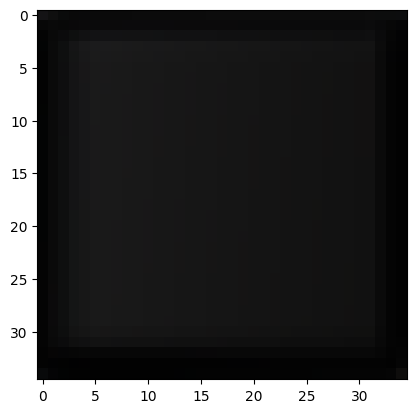

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7360.88916015625, epoch:209/1000


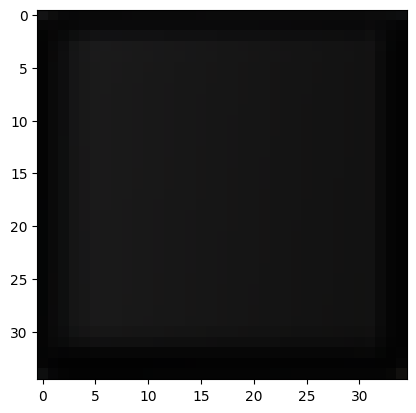

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7360.392578125, epoch:210/1000


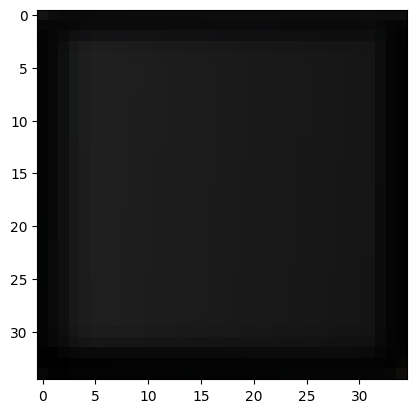

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.83837890625, epoch:211/1000


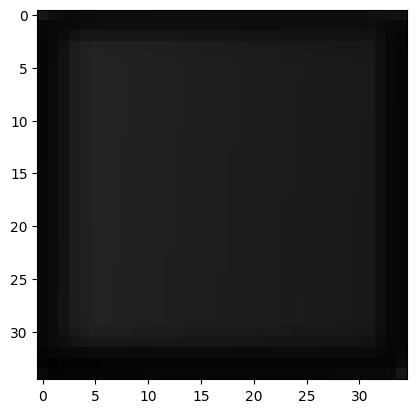

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.61572265625, epoch:212/1000


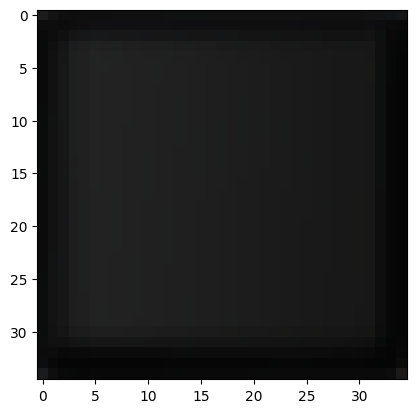

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.8349609375, epoch:213/1000


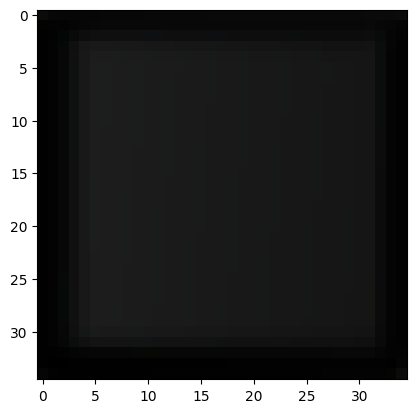

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7359.876953125, epoch:214/1000


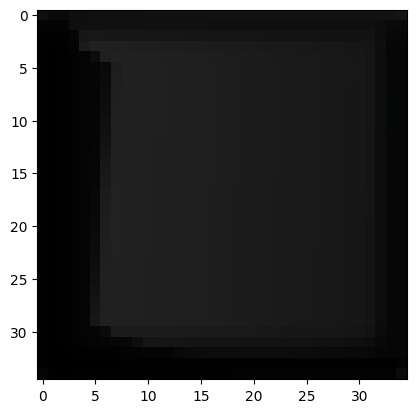

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.28515625, epoch:215/1000


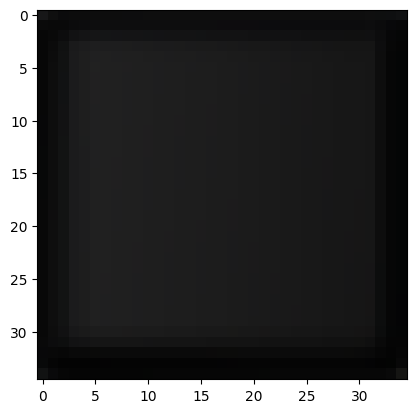

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.83642578125, epoch:216/1000


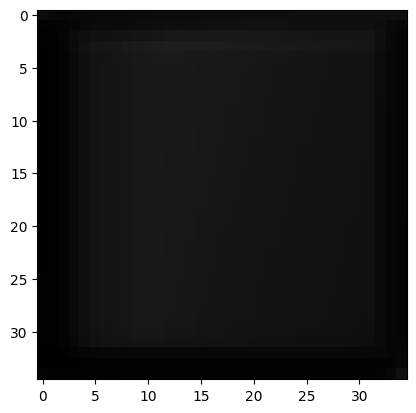

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7359.60400390625, epoch:217/1000


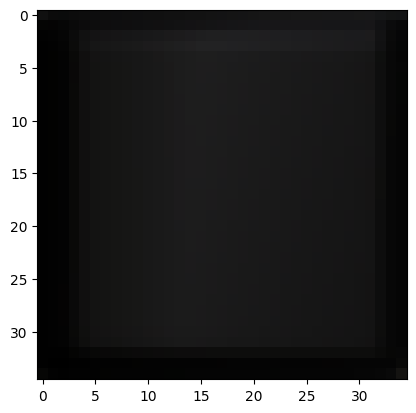

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.85546875, epoch:218/1000


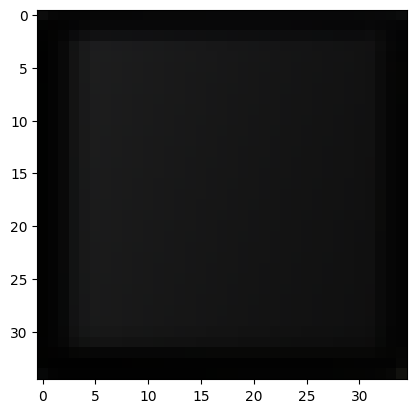

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7360.84716796875, epoch:219/1000


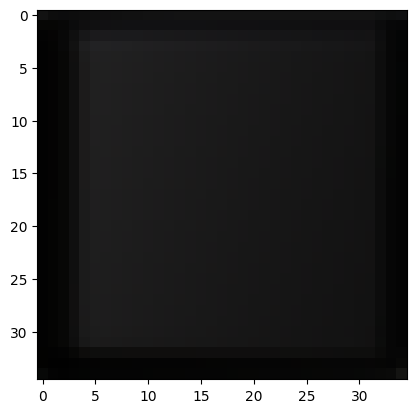

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7358.890625, epoch:220/1000


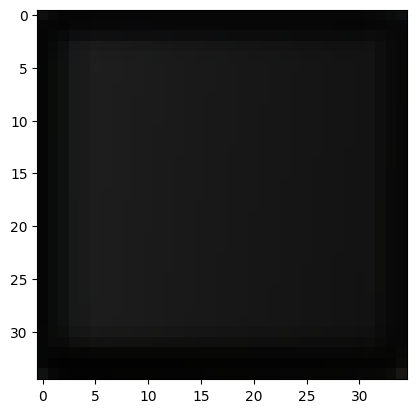

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.82861328125, epoch:221/1000


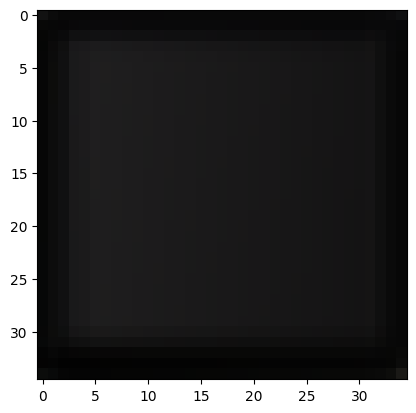

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.8203125, epoch:222/1000


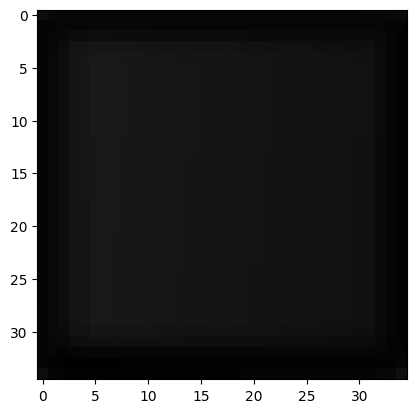

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.81396484375, epoch:223/1000


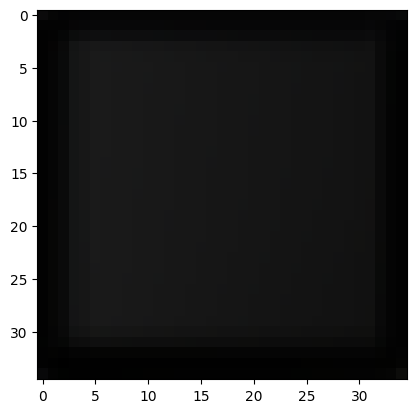

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.5234375, epoch:224/1000


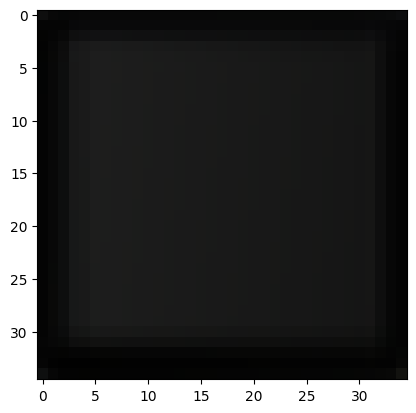

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.8056640625, epoch:225/1000


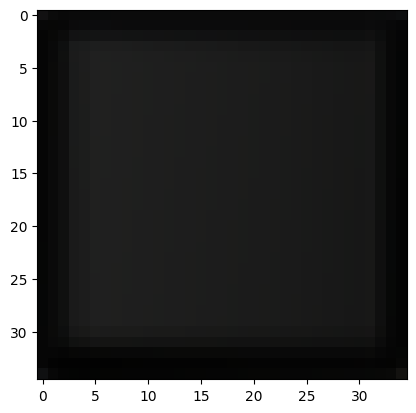

100%|██████████| 300/300 [01:09<00:00,  4.33it/s]

loss: 7360.35693359375, epoch:226/1000


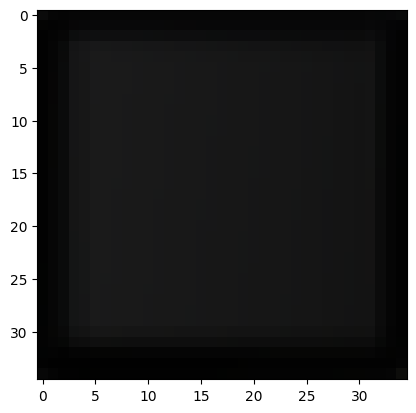

100%|██████████| 300/300 [01:09<00:00,  4.35it/s]

loss: 7360.525390625, epoch:227/1000


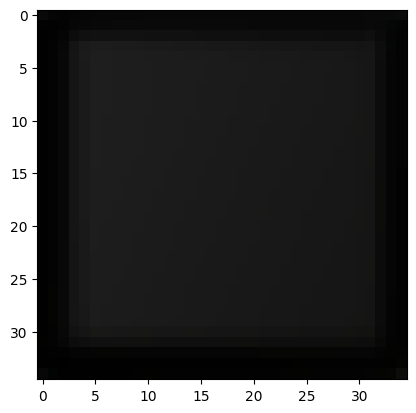

100%|██████████| 300/300 [01:09<00:00,  4.32it/s]

loss: 7360.78857421875, epoch:228/1000


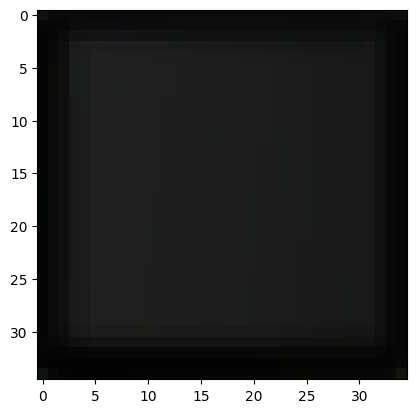

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.79150390625, epoch:229/1000


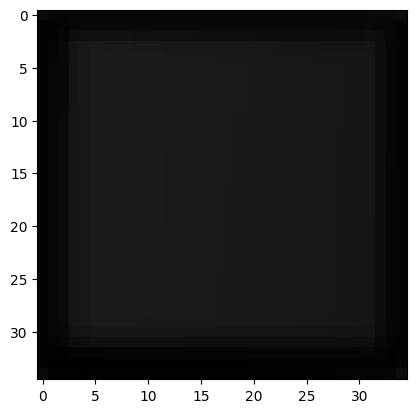

100%|██████████| 300/300 [01:10<00:00,  4.25it/s]

loss: 7360.705078125, epoch:230/1000


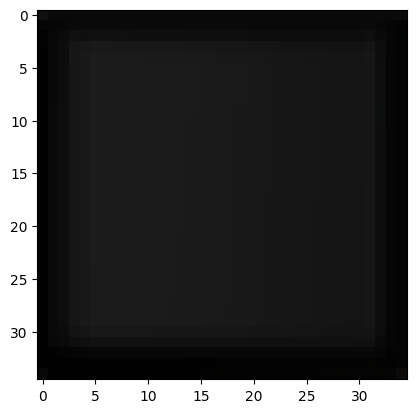

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.76708984375, epoch:231/1000


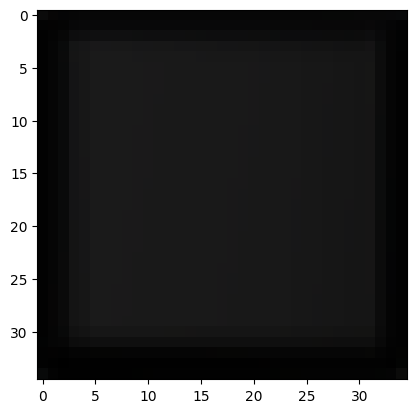

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.78466796875, epoch:232/1000


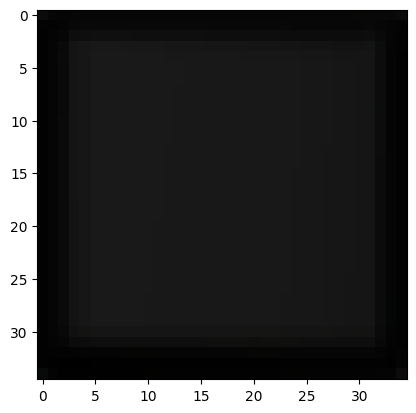

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7358.466796875, epoch:233/1000


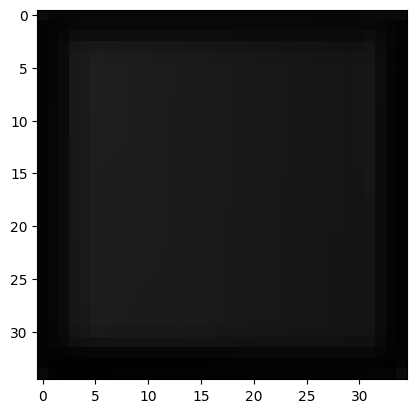

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.796875, epoch:234/1000


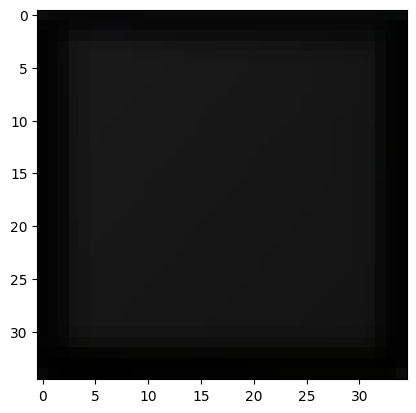

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.79296875, epoch:235/1000


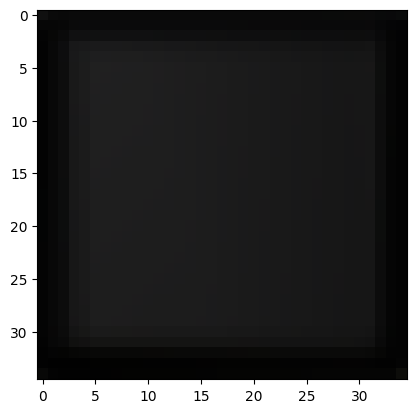

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.7919921875, epoch:236/1000


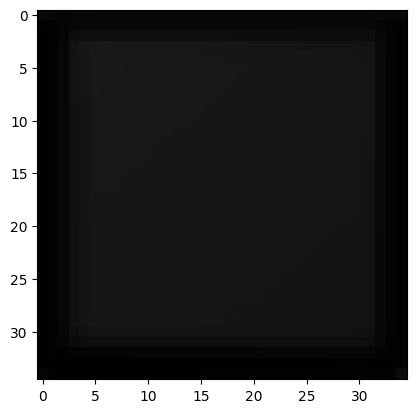

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.7890625, epoch:237/1000


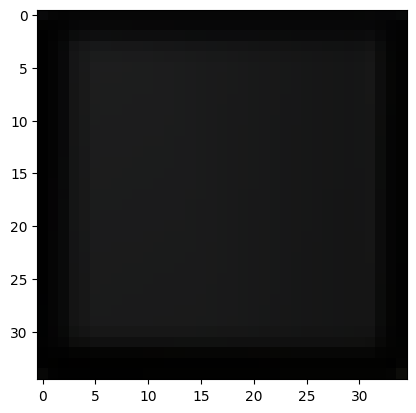

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.78369140625, epoch:238/1000


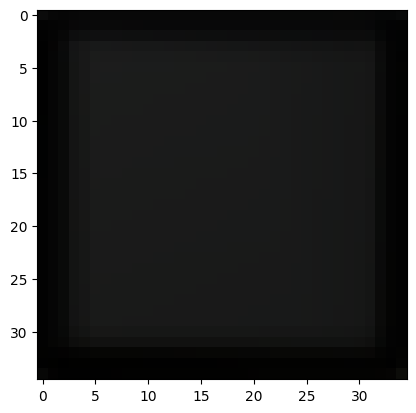

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.78173828125, epoch:239/1000


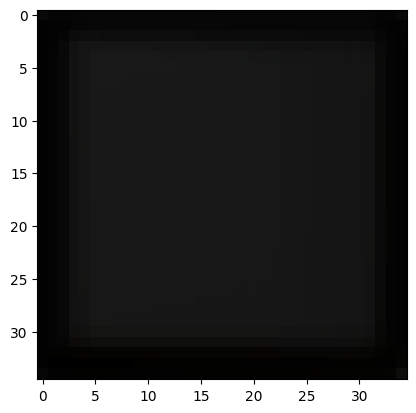

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.77978515625, epoch:240/1000


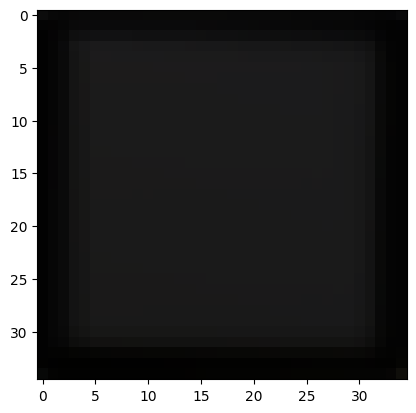

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.7734375, epoch:241/1000


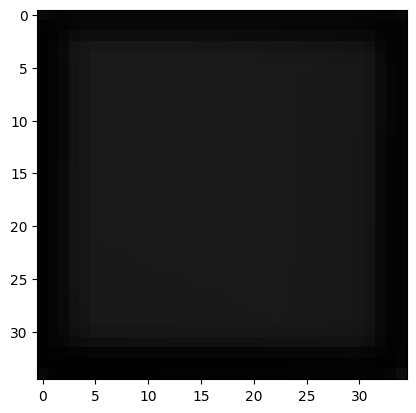

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.7734375, epoch:242/1000


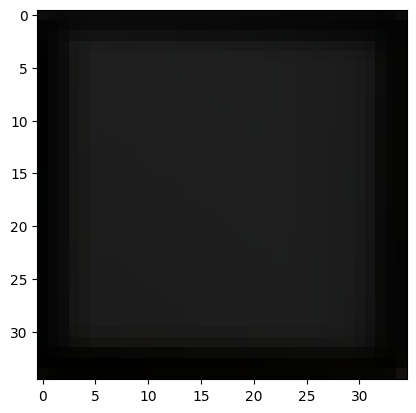

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]


loss: 7360.77001953125, epoch:243/1000


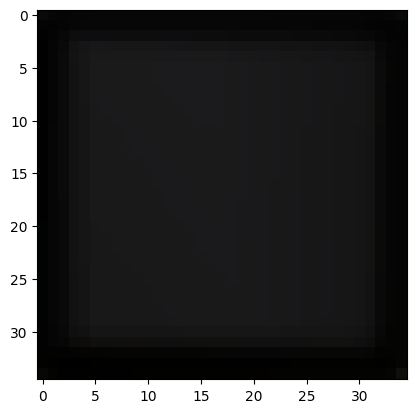

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.71533203125, epoch:244/1000


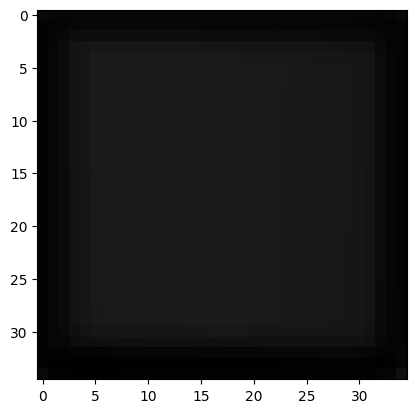

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7360.76708984375, epoch:245/1000


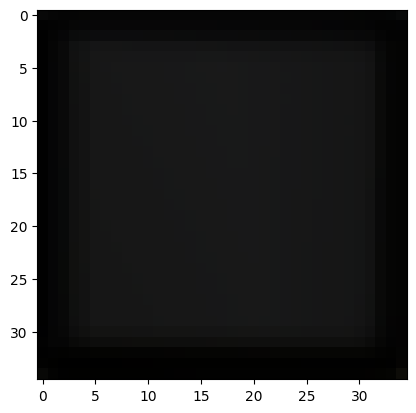

100%|██████████| 300/300 [01:10<00:00,  4.23it/s]


loss: 7360.6318359375, epoch:246/1000


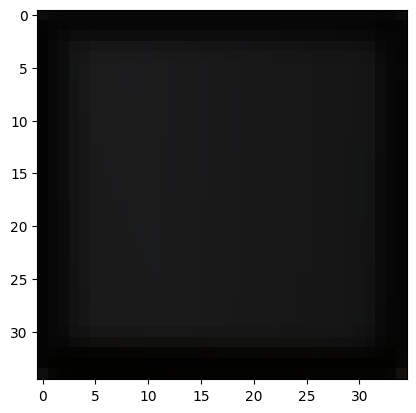

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.587890625, epoch:247/1000


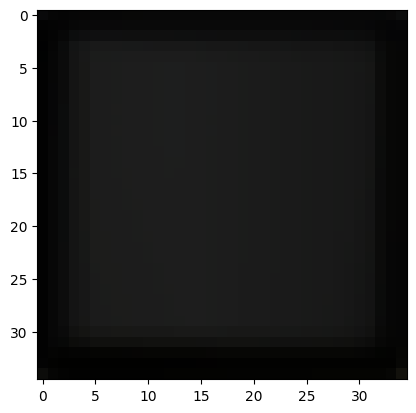

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.7734375, epoch:248/1000


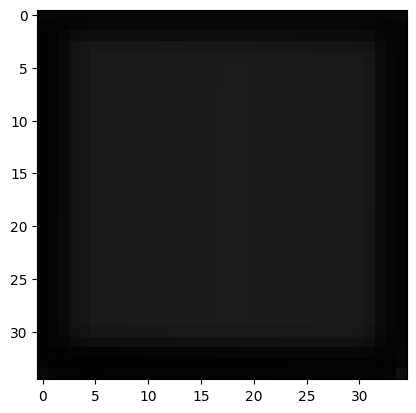

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.77001953125, epoch:249/1000


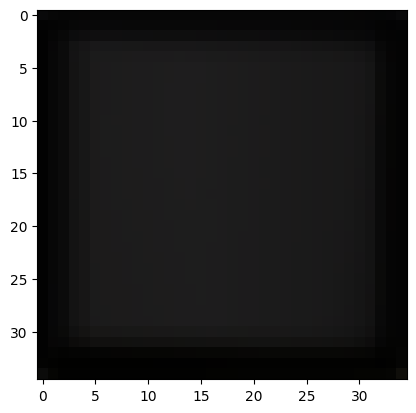

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.7646484375, epoch:250/1000


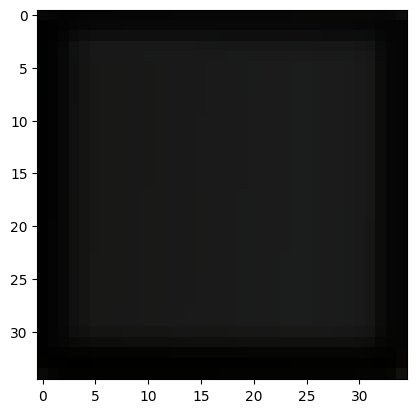

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.71533203125, epoch:251/1000


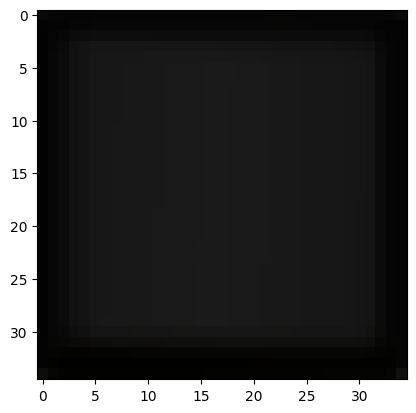

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.34130859375, epoch:252/1000


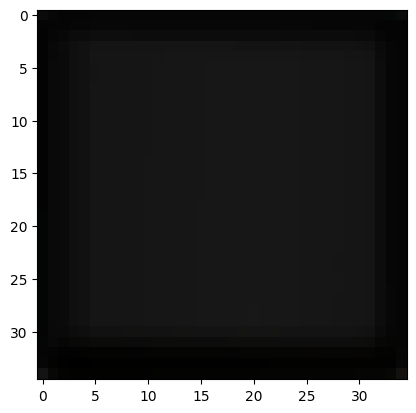

100%|██████████| 300/300 [01:09<00:00,  4.32it/s]


loss: 7359.6630859375, epoch:253/1000


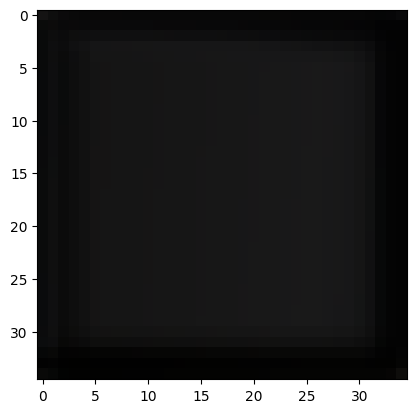

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.330078125, epoch:254/1000


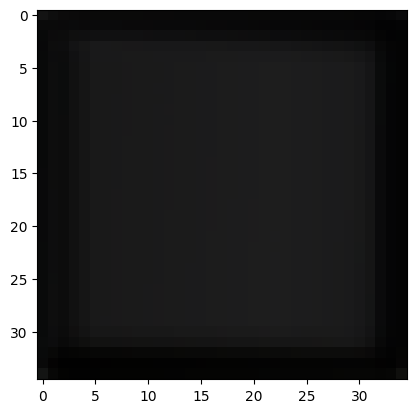

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.43017578125, epoch:255/1000


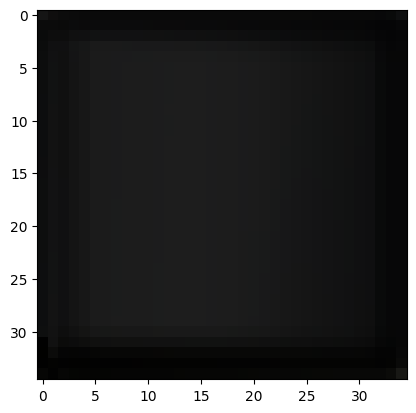

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.3310546875, epoch:256/1000


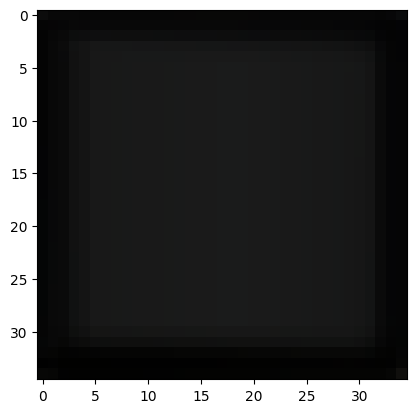

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7359.20068359375, epoch:257/1000


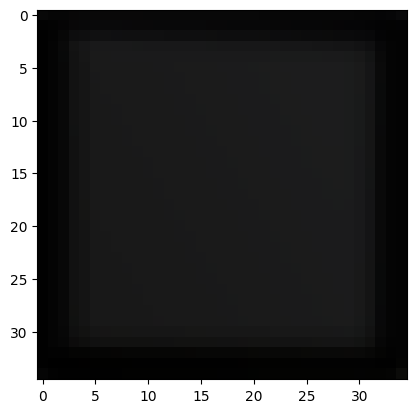

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.66357421875, epoch:258/1000


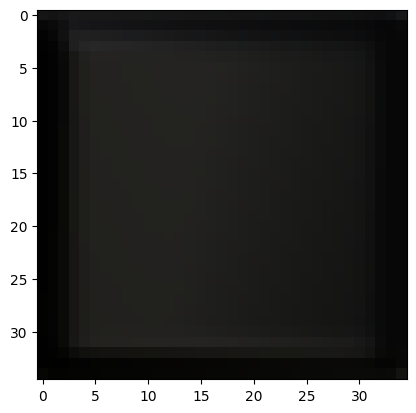

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.64990234375, epoch:259/1000


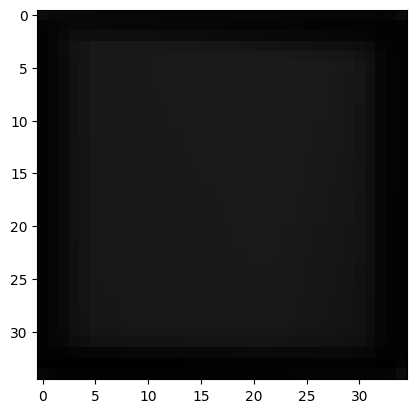

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.23193359375, epoch:260/1000


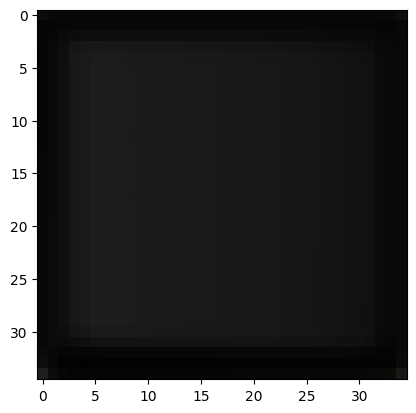

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.69384765625, epoch:261/1000


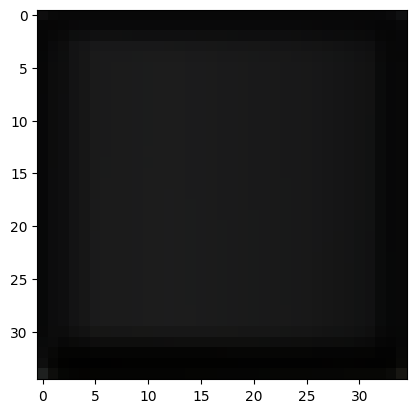

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.76513671875, epoch:262/1000


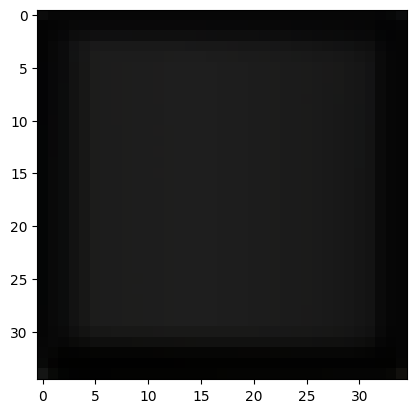

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.68017578125, epoch:263/1000


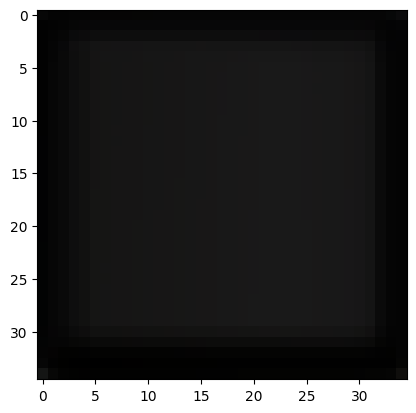

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.62109375, epoch:264/1000


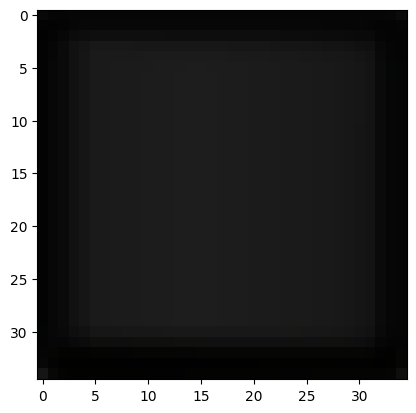

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7360.2392578125, epoch:265/1000


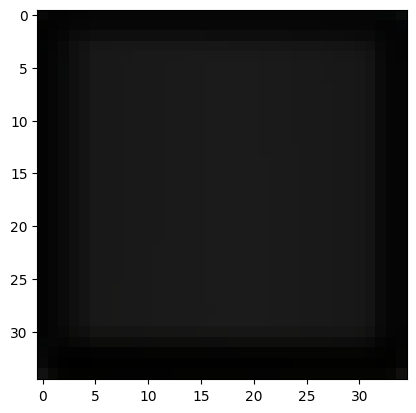

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7359.83740234375, epoch:266/1000


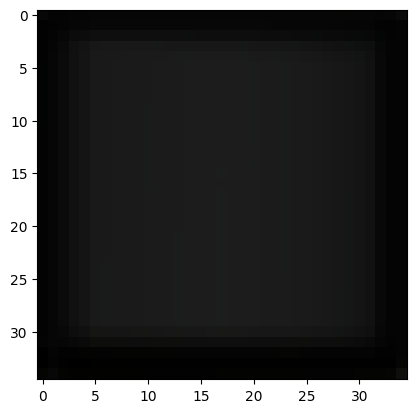

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7360.48291015625, epoch:267/1000


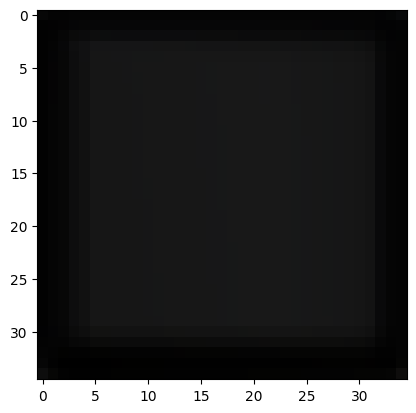

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7360.33154296875, epoch:268/1000


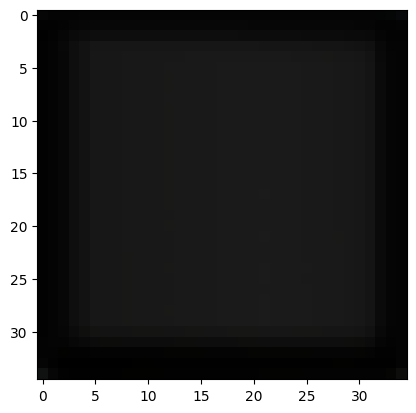

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7360.52099609375, epoch:269/1000


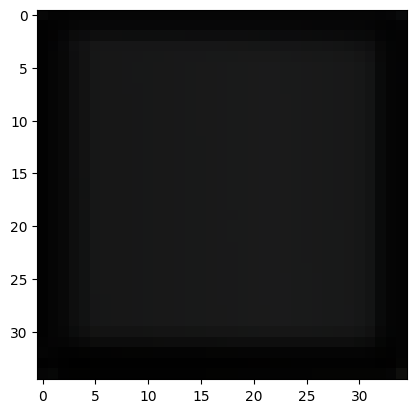

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7360.49365234375, epoch:270/1000


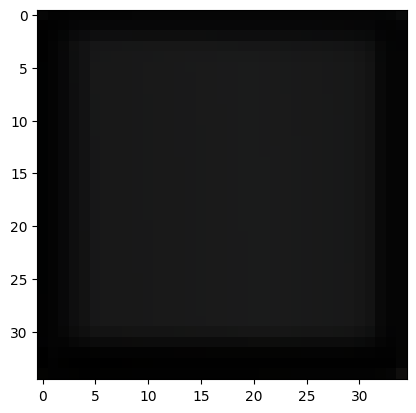

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7358.73828125, epoch:271/1000


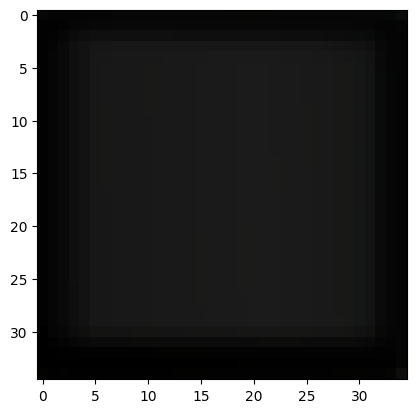

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7359.84765625, epoch:272/1000


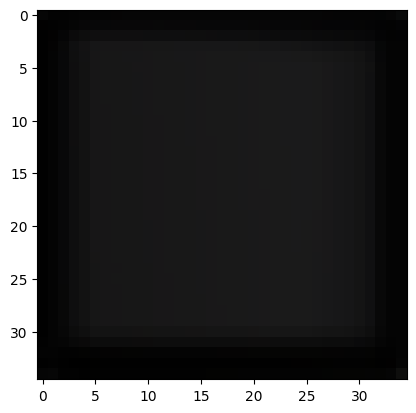

100%|██████████| 300/300 [01:11<00:00,  4.22it/s]

loss: 7359.677734375, epoch:273/1000


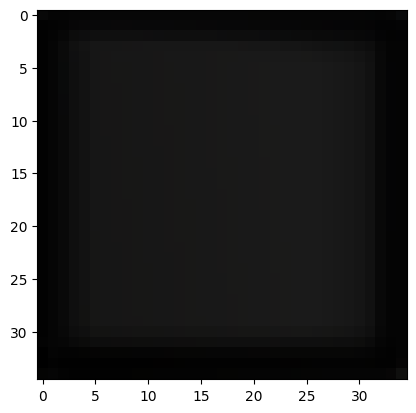

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7359.1767578125, epoch:274/1000


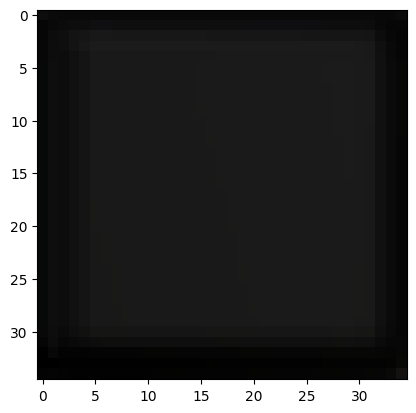

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7358.44970703125, epoch:275/1000


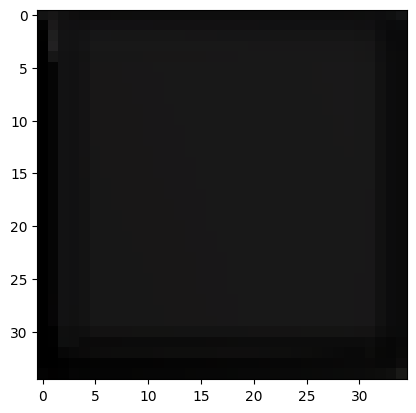

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7357.9169921875, epoch:276/1000


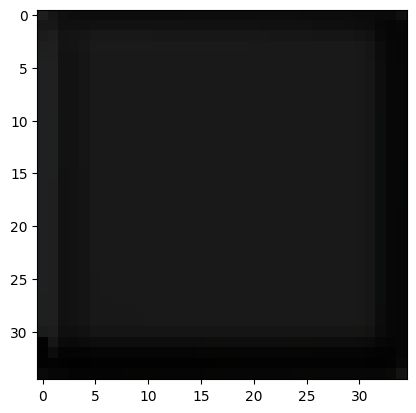

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7361.14013671875, epoch:277/1000


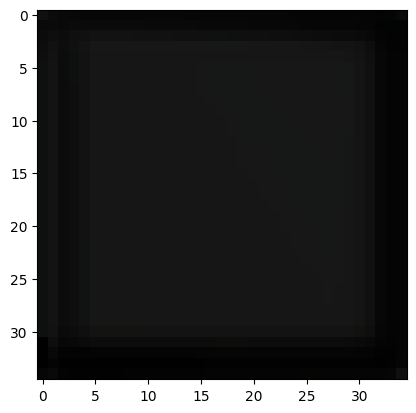

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7359.638671875, epoch:278/1000


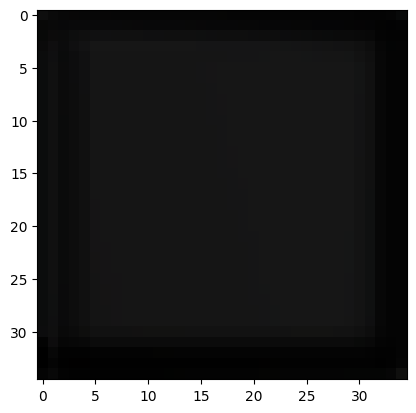

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7359.19775390625, epoch:279/1000


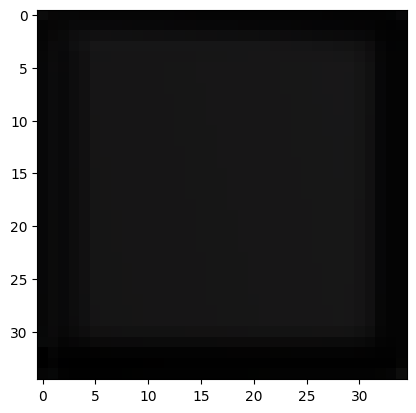

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]


loss: 7359.32568359375, epoch:280/1000


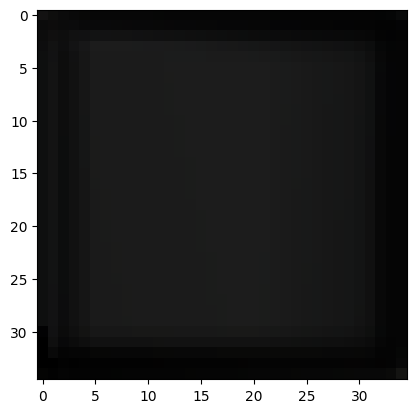

100%|██████████| 300/300 [01:09<00:00,  4.30it/s]

loss: 7358.28466796875, epoch:281/1000


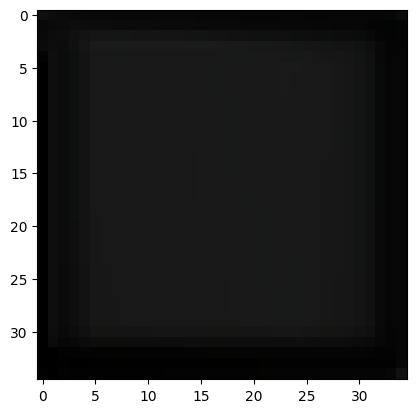

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]


loss: 7356.9248046875, epoch:282/1000


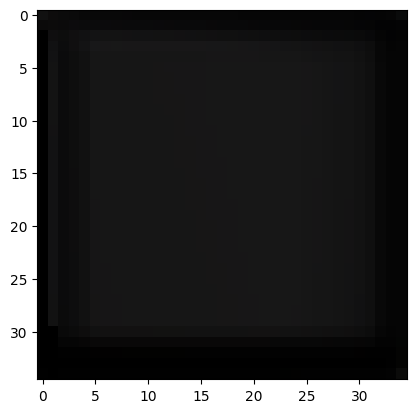

100%|██████████| 300/300 [01:09<00:00,  4.29it/s]

loss: 7375.95751953125, epoch:283/1000


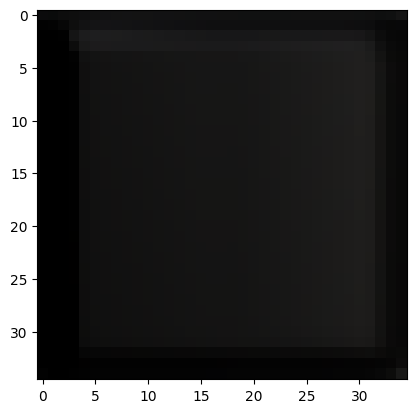

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7361.857421875, epoch:284/1000


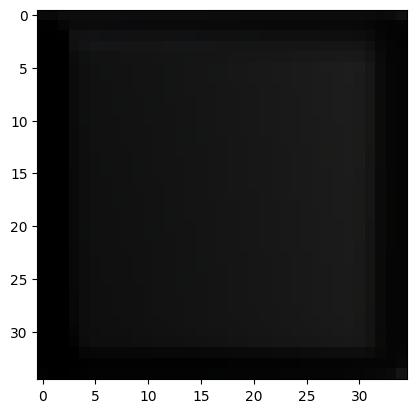

100%|██████████| 300/300 [01:10<00:00,  4.27it/s]

loss: 7363.41455078125, epoch:285/1000


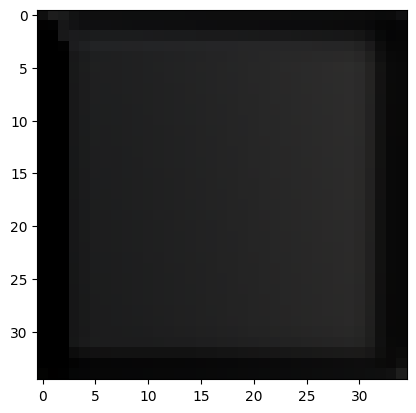

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7376.7578125, epoch:286/1000


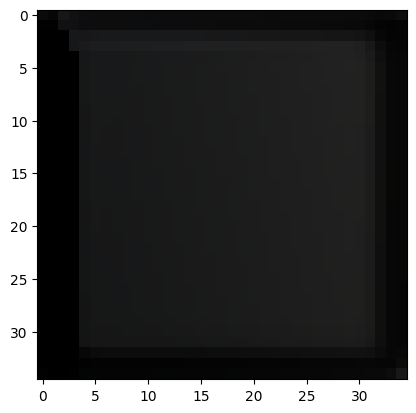

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]


loss: 7361.11181640625, epoch:287/1000


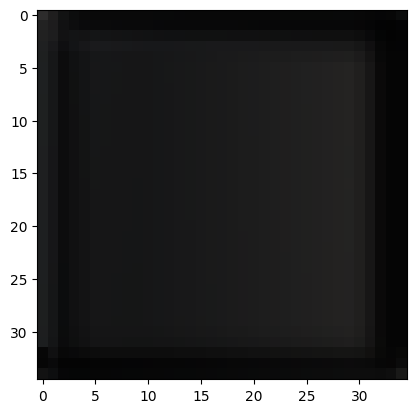

100%|██████████| 300/300 [01:10<00:00,  4.28it/s]

loss: 7361.10205078125, epoch:288/1000


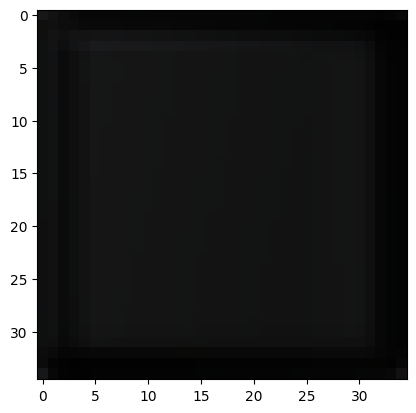

100%|██████████| 300/300 [01:10<00:00,  4.26it/s]

loss: 7361.001953125, epoch:289/1000


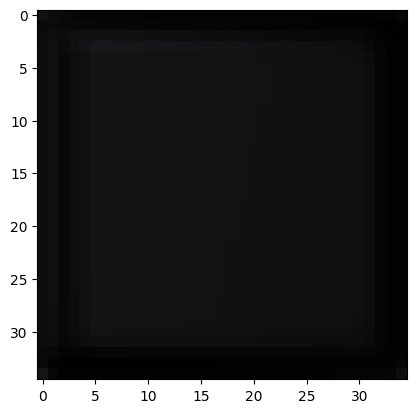

100%|██████████| 300/300 [01:09<00:00,  4.31it/s]

loss: 7360.32763671875, epoch:290/1000


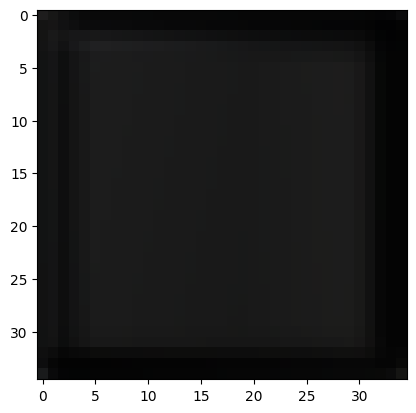

  4%|▍         | 13/300 [00:05<02:05,  2.29it/s]


KeyboardInterrupt: 

In [9]:
iteration=0

for epohc in range(num_epochs):
    closs=0
    for idx,batch in enumerate(tqdm.tqdm(train_dataloader)):

        images=transform(batch['image']).to(device)
        mask=transform(batch['mask'][:,1:,0,:]).to(device)

        optimizer.zero_grad()
        recon=model(images)
        recon,rmask=model(images,get_masks=True)
        loss=critres(recon,images)+critmask(rmask,mask)
        loss.backward()
        optimizer.step()
        
        closs+=loss.detach()
        del loss,recon,images
    loss_evolution+=[closs/len(train_dataloader)]
    sched.step()
    print(f"loss: {closs}, epoch:{epohc}/{num_epochs}")
    ##
    with torch.no_grad():
        plt.imshow(model(visual).detach().to('cpu')[0,:,:,:].permute(1,2,0))
        plt.show()
    ##
    if epohc%10==0:
        torch.save(model.state_dict(), model_dir+"/autosave.pt")
        with open(model_dir+'/stats.pkl', mode='wb') as file:
            pickle.dump(loss_evolution,file)

In [ ]:
torch.save(model.state_dict(), model_dir+"/epoch264+29perfinal.pt")

In [12]:
print([float(i.to('cpu').detach().numpy()) for i in loss_evolution])

[29.240564346313477, 24.71419906616211, 24.649879455566406, 24.601652145385742, 24.58757781982422, 24.5634822845459, 24.557382583618164, 24.552936553955078, 24.551794052124023, 24.548980712890625, 24.54758644104004, 24.546619415283203, 24.551982879638672, 24.545631408691406, 24.545146942138672, 24.54481315612793, 24.544559478759766, 24.544422149658203, 24.544876098632812, 24.544227600097656, 24.54401206970215, 24.54391098022461, 24.543848037719727, 24.543787002563477, 24.543609619140625, 24.54350471496582, 24.543434143066406, 24.543312072753906, 24.543270111083984, 24.54327392578125, 24.542892456054688, 24.542551040649414, 24.541969299316406, 24.541149139404297, 24.540117263793945, 24.53953742980957, 24.538522720336914, 24.537944793701172, 24.537410736083984, 24.537073135375977, 24.53682518005371, 24.536630630493164, 24.536483764648438, 24.536388397216797, 24.536304473876953, 24.53624725341797, 24.536197662353516, 24.536157608032227, 24.536182403564453, 24.536109924316406, 24.536081314

In [13]:
test_set=Tetrominoes("data/Tetrominoes",download=True,split="Test")
test_dataloader=torch.utils.data.DataLoader(train_set,batch_size=batch_size,shuffle=True,num_workers=num_workers)

In [14]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 22.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [15]:
import sklearn
import numpy as np

In [16]:
score=[]
model.eval()
with torch.no_grad():
    for test in tqdm.tqdm(test_set):
        img=transform(test["image"]).to(device).unsqueeze(0)
        _,masks=model(img,get_masks=True)
        lbl=torch.argmax(masks,dim=1)[0,:,:].to("cpu").flatten()
        labels=((((sum((it+1)*(v.flatten().numpy().astype(np.int32)//255) for it,v in enumerate(test['mask'][:,0,:,:]))))))
        score.append(sklearn.metrics.adjusted_rand_score(labels,lbl))
ari=np.mean(score)
print(f"ARI for meanshift rgb is ari={ari}")

100%|██████████| 5000/5000 [00:15<00:00, 321.80it/s]

ARI for meanshift rgb is ari=-0.00611228459969274
